## Part One: Determining What's Useful and What's Sensitive

Before applying any privacy techniques, we need to:
- Understand the data completeness
- Identify potential sensitive columns
- Identify useful features for prediction
- Determine which columns to use, remove, or protect

**Dataset Variables:**
1. PatientId - Identification of a patient (DIRECT IDENTIFIER - SENSITIVE)
2. AppointmentID - Identification of each appointment (DIRECT IDENTIFIER)
3. Gender - Male or Female (QUASI-IDENTIFIER)
4. ScheduledDay - The day someone called or registered the appointment (USEFUL)
5. AppointmentDay - The actual appointment day (USEFUL)
6. Age - Patient's age (QUASI-IDENTIFIER + USEFUL)
7. Neighbourhood - Where the appointment takes place (QUASI-IDENTIFIER)
8. Scholarship - Bolsa Família program participation (SENSITIVE + USEFUL)
9. Hipertension - Medical condition (SENSITIVE + USEFUL)
10. Diabetes - Medical condition (SENSITIVE + USEFUL)
11. Alcoholism - Medical condition (SENSITIVE + USEFUL)
12. Handcap - Disability level (SENSITIVE + USEFUL)
13. SMS_received - Number of SMS reminders (USEFUL)
14. No-show - Target variable: Did the patient show up? (TARGET - SENSITIVE)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Load the dataset
df = pd.read_csv('Database.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head(10)

Dataset shape: (110527, 14)

First few rows:


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,No
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,Yes
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0,0,0,0,0,0,Yes
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0,0,0,0,0,0,No
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0,0,0,0,0,0,No


In [3]:
# Data info and completeness
print("Dataset Information:")
print("="*60)
df.info()
print("\n" + "="*60)
print("\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
}).sort_values('Missing Count', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("\n✓ No missing values found - dataset is complete!")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage

In [4]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [5]:
# Analyze categorical variables
print("Categorical Variables Distribution:")
print("="*60)

categorical_cols = ['Gender', 'Scholarship', 'Hipertension', 'Diabetes', 
                   'Alcoholism', 'Handcap', 'SMS_received', 'No-show']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())
        print(f"Unique values: {df[col].nunique()}")

Categorical Variables Distribution:

Gender:
Gender
F    71840
M    38687
Name: count, dtype: int64
Unique values: 2

Scholarship:
Scholarship
0    99666
1    10861
Name: count, dtype: int64
Unique values: 2

Hipertension:
Hipertension
0    88726
1    21801
Name: count, dtype: int64
Unique values: 2

Diabetes:
Diabetes
0    102584
1      7943
Name: count, dtype: int64
Unique values: 2

Alcoholism:
Alcoholism
0    107167
1      3360
Name: count, dtype: int64
Unique values: 2

Handcap:
Handcap
0    108286
1      2042
2       183
3        13
4         3
Name: count, dtype: int64
Unique values: 5

SMS_received:
SMS_received
0    75045
1    35482
Name: count, dtype: int64
Unique values: 2

No-show:
No-show
No     88208
Yes    22319
Name: count, dtype: int64
Unique values: 2


In [6]:
# Analyze Neighbourhood distribution
print(f"Number of unique neighbourhoods: {df['Neighbourhood'].nunique()}")
print(f"\nTop 20 neighbourhoods by appointment count:")
neighbourhood_counts = df['Neighbourhood'].value_counts().head(20)
print(neighbourhood_counts)

Number of unique neighbourhoods: 81

Top 20 neighbourhoods by appointment count:
Neighbourhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4431
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           3132
SANTA MARTHA         3131
JESUS DE NAZARETH    2853
BONFIM               2773
SANTO ANTÔNIO        2746
SANTO ANDRÉ          2571
CARATOÍRA            2565
JABOUR               2509
SÃO PEDRO            2448
ILHA DO PRÍNCIPE     2266
NOVA PALESTINA       2264
ANDORINHAS           2262
DA PENHA             2217
ROMÃO                2215
Name: count, dtype: int64


Age Statistics:
count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

Age range: -1 to 115
Negative or suspicious ages: 1


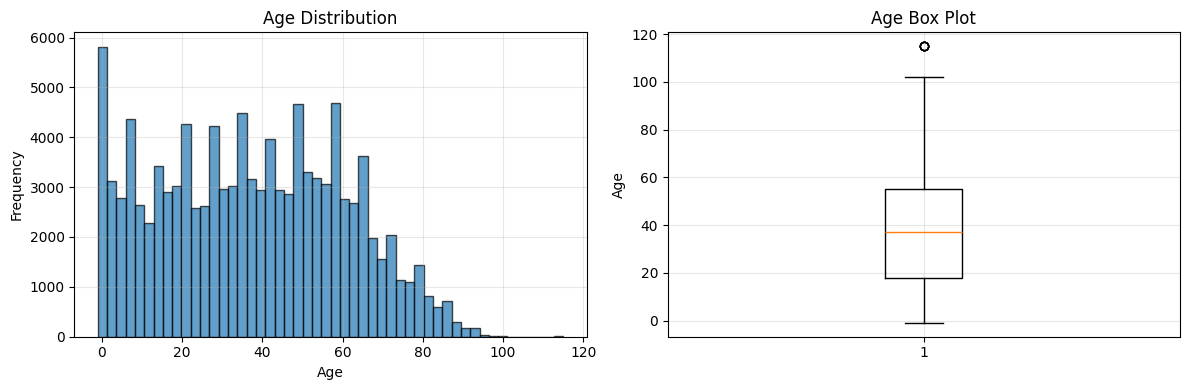

In [7]:
# Analyze Age distribution
print("Age Statistics:")
print(df['Age'].describe())
print(f"\nAge range: {df['Age'].min()} to {df['Age'].max()}")
print(f"Negative or suspicious ages: {len(df[df['Age'] < 0])}")

# Visualize age distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['Age'])
plt.ylabel('Age')
plt.title('Age Box Plot')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Target Variable Analysis: No-show

No-show distribution:
No: 88208 (79.81%)
Yes: 22319 (20.19%)


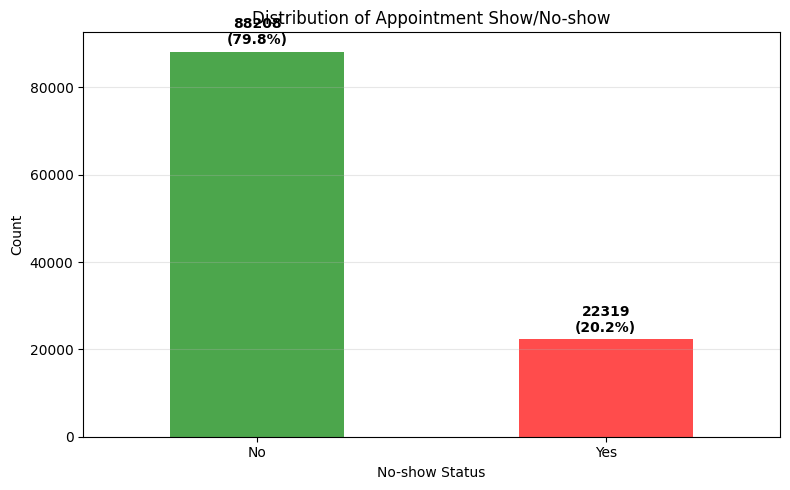


⚠️ Class imbalance: 79.8% showed up vs 20.2% no-show


In [8]:
# Analyze the target variable: No-show
print("Target Variable Analysis: No-show")
print("="*60)
noshow_counts = df['No-show'].value_counts()
noshow_pct = df['No-show'].value_counts(normalize=True) * 100

print(f"\nNo-show distribution:")
for val, count in noshow_counts.items():
    print(f"{val}: {count} ({noshow_pct[val]:.2f}%)")

# Visualize
plt.figure(figsize=(8, 5))
noshow_counts.plot(kind='bar', color=['green', 'red'], alpha=0.7)
plt.xlabel('No-show Status')
plt.ylabel('Count')
plt.title('Distribution of Appointment Show/No-show')
plt.xticks(rotation=0)
plt.grid(alpha=0.3, axis='y')
for i, (val, count) in enumerate(noshow_counts.items()):
    plt.text(i, count + 1000, f'{count}\n({noshow_pct[val]:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n⚠️ Class imbalance: {noshow_pct['No']:.1f}% showed up vs {noshow_pct['Yes']:.1f}% no-show")

## Data Privacy Assessment

**Classification of Columns:**

**Direct Identifiers (Must Remove):**
- `PatientId`: Can directly identify individuals
- `AppointmentID`: Can link to external records

**Quasi-Identifiers (Need Protection via k-anonymity/l-diversity/t-closeness):**
- `Age`: Can be combined with other attributes to re-identify
- `Gender`: Binary attribute that narrows identification
- `Neighbourhood`: Geographic information - many unique values (potential re-identification)

**Sensitive Attributes (Need Protection):**
- `Scholarship`: Indicates socioeconomic status (Bolsa Família)
- `Hipertension`: Medical condition (protected health information)
- `Diabetes`: Medical condition (protected health information)
- `Alcoholism`: Medical condition (protected health information)
- `Handcap`: Disability status (protected information)
- `No-show`: Target variable - could reveal health-seeking behavior

**Utility Features (Keep and possibly protect):**
- `ScheduledDay` and `AppointmentDay`: Temporal features - useful for prediction
- `SMS_received`: Behavioral intervention - useful feature
- All medical conditions: Critical for ML prediction

**Privacy Strategy:**
1. **Remove** direct identifiers (PatientId, AppointmentID)
2. **Apply k-anonymity/l-diversity/t-closeness** on quasi-identifiers (Age, Gender, Neighbourhood)
3. **Apply differential privacy** on sensitive medical conditions
4. **Generalize** temporal data to reduce precision
5. Keep useful features for ML while ensuring privacy

## Part Two: Determining the Approach for Protecting the Columns

Based on Part One analysis, we now determine the privacy protection approach.

**Key Findings:**
- ✓ Dataset is complete (no missing values)
- ⚠️ Age has outliers (-1, 115) that need cleaning
- ⚠️ 81 unique neighbourhoods - high cardinality quasi-identifier
- ⚠️ Class imbalance: 79.8% show vs 20.2% no-show

**Privacy Protection Strategy:**

### 1. Data Minimization & Direct Identifier Removal
- **Remove**: `PatientId`, `AppointmentID` (direct identifiers - no utility for prediction)

### 2. K-Anonymity on Quasi-Identifiers
Apply k-anonymity (k=5 minimum) on:
- **Age**: Generalize into age bins (0-17, 18-30, 31-45, 46-60, 61-75, 76+)
- **Gender**: Keep as-is (binary - low risk)
- **Neighbourhood**: Generalize to reduce from 81 to ~10-15 regions or use top-k approach

### 3. L-Diversity for Sensitive Attributes
Ensure each k-anonymous group has diverse values of:
- **No-show** (target variable - sensitive as it reveals behavior)
- Medical conditions combined

### 4. T-Closeness
Ensure sensitive attribute distribution in each partition is close to global distribution:
- Focus on `No-show` (20% no-show rate should be preserved in partitions)

### 5. Differential Privacy for Medical Conditions
Apply randomized response to binary medical features:
- `Hipertension`, `Diabetes`, `Alcoholism`, `Handcap`
- Use p=0.3, q=0.5 for moderate privacy (epsilon ≈ 2.4)

### 6. Temporal Generalization
- Extract useful features: days between scheduling and appointment, day of week, time of day
- Remove exact timestamps after feature engineering

**Data Leakage Considerations:**
- Rare combinations of (Age, Gender, Neighbourhood, Medical conditions) can re-identify
- Medical conditions might be correlated, reducing effective l-diversity
- Scholarship status is sensitive socioeconomic indicator
- SMS_received is behavioral but less sensitive

In [9]:
# Create a working copy for protection
df_protected = df.copy()

# Step 1: Remove direct identifiers
print("Step 1: Removing Direct Identifiers")
print("="*60)
direct_identifiers = ['PatientId', 'AppointmentID']
df_protected = df_protected.drop(columns=direct_identifiers)
print(f"Removed columns: {direct_identifiers}")
print(f"New shape: {df_protected.shape}")
print(f"Remaining columns: {list(df_protected.columns)}")

Step 1: Removing Direct Identifiers
Removed columns: ['PatientId', 'AppointmentID']
New shape: (110527, 12)
Remaining columns: ['Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


In [10]:
# Step 2: Clean and prepare data
print("\nStep 2: Data Cleaning")
print("="*60)

# Fix negative age
df_protected.loc[df_protected['Age'] < 0, 'Age'] = 0
print(f"Fixed {(df['Age'] < 0).sum()} negative age values")

# Convert date columns to datetime
df_protected['ScheduledDay'] = pd.to_datetime(df_protected['ScheduledDay'])
df_protected['AppointmentDay'] = pd.to_datetime(df_protected['AppointmentDay'])

# Create temporal features BEFORE removing timestamps
df_protected['DaysBetween'] = (df_protected['AppointmentDay'] - df_protected['ScheduledDay']).dt.days
df_protected['AppointmentDayOfWeek'] = df_protected['AppointmentDay'].dt.dayofweek
df_protected['AppointmentMonth'] = df_protected['AppointmentDay'].dt.month
df_protected['ScheduledDayOfWeek'] = df_protected['ScheduledDay'].dt.dayofweek

print(f"Created temporal features: DaysBetween, AppointmentDayOfWeek, AppointmentMonth, ScheduledDayOfWeek")

# Remove exact timestamps (already extracted useful features)
df_protected = df_protected.drop(columns=['ScheduledDay', 'AppointmentDay'])
print(f"Removed exact timestamps")

# Convert No-show to binary (0=No, 1=Yes)
df_protected['NoShow_binary'] = (df_protected['No-show'] == 'Yes').astype(int)

print(f"\nCleaned data shape: {df_protected.shape}")
df_protected.head()


Step 2: Data Cleaning
Fixed 1 negative age values
Fixed 1 negative age values
Created temporal features: DaysBetween, AppointmentDayOfWeek, AppointmentMonth, ScheduledDayOfWeek
Removed exact timestamps

Cleaned data shape: (110527, 15)
Created temporal features: DaysBetween, AppointmentDayOfWeek, AppointmentMonth, ScheduledDayOfWeek
Removed exact timestamps

Cleaned data shape: (110527, 15)


,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,DaysBetween,AppointmentDayOfWeek,AppointmentMonth,ScheduledDayOfWeek,NoShow_binary
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,No,-1,4,4,4,0
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,No,-1,4,4,4,0
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,No,-1,4,4,4,0
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,-1,4,4,4,0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,No,-1,4,4,4,0


In [11]:
# Step 3: Analyze re-identification risk before anonymization
print("Step 3: Re-identification Risk Analysis")
print("="*60)

# Check uniqueness of quasi-identifier combinations
quasi_identifiers = ['Age', 'Gender', 'Neighbourhood']
unique_combinations = df_protected.groupby(quasi_identifiers).size().reset_index(name='count')
print(f"\nUnique combinations of {quasi_identifiers}:")
print(f"Total unique combinations: {len(unique_combinations)}")
print(f"Combinations with only 1 person: {len(unique_combinations[unique_combinations['count'] == 1])}")
print(f"Combinations with < 5 people: {len(unique_combinations[unique_combinations['count'] < 5])}")
print(f"Percentage of records at risk (k<5): {(unique_combinations[unique_combinations['count'] < 5]['count'].sum() / len(df_protected) * 100):.2f}%")

# Show most unique combinations
print("\nMost unique (risky) combinations:")
print(unique_combinations.nsmallest(10, 'count'))

Step 3: Re-identification Risk Analysis

Unique combinations of ['Age', 'Gender', 'Neighbourhood']:
Total unique combinations: 11151
Combinations with only 1 person: 1699
Combinations with < 5 people: 4750
Percentage of records at risk (k<5): 9.48%

Most unique (risky) combinations:
     Age Gender   Neighbourhood  count
4      0      F  BENTO FERREIRA      1
17     0      F  ENSEADA DO SUÁ      1
21     0      F       FRADINHOS      1
43     0      F        NAZARETH      1
57     0      F     SANTA LÚCIA      1
71     0      F   UNIVERSITÁRIO      1
116    0      M  PARQUE MOSCOSO      1
148    1      F       BOA VISTA      1
181    1      F   MATA DA PRAIA      1
183    1      F  MÁRIO CYPRESTE      1

Unique combinations of ['Age', 'Gender', 'Neighbourhood']:
Total unique combinations: 11151
Combinations with only 1 person: 1699
Combinations with < 5 people: 4750
Percentage of records at risk (k<5): 9.48%

Most unique (risky) combinations:
     Age Gender   Neighbourhood  count
4   


Step 4: Neighbourhood to Region Mapping

Original neighbourhoods: 81
Geographic regions: 9

Region distribution:
Region
Maruípe            27516
Goiabeiras         18561
Santo Antônio      15907
Jucutuquara        11204
São Pedro          11071
Centro              8963
Jardim Camburi      7814
Jardim da Penha     5889
Praia do Canto      3602
Name: count, dtype: int64


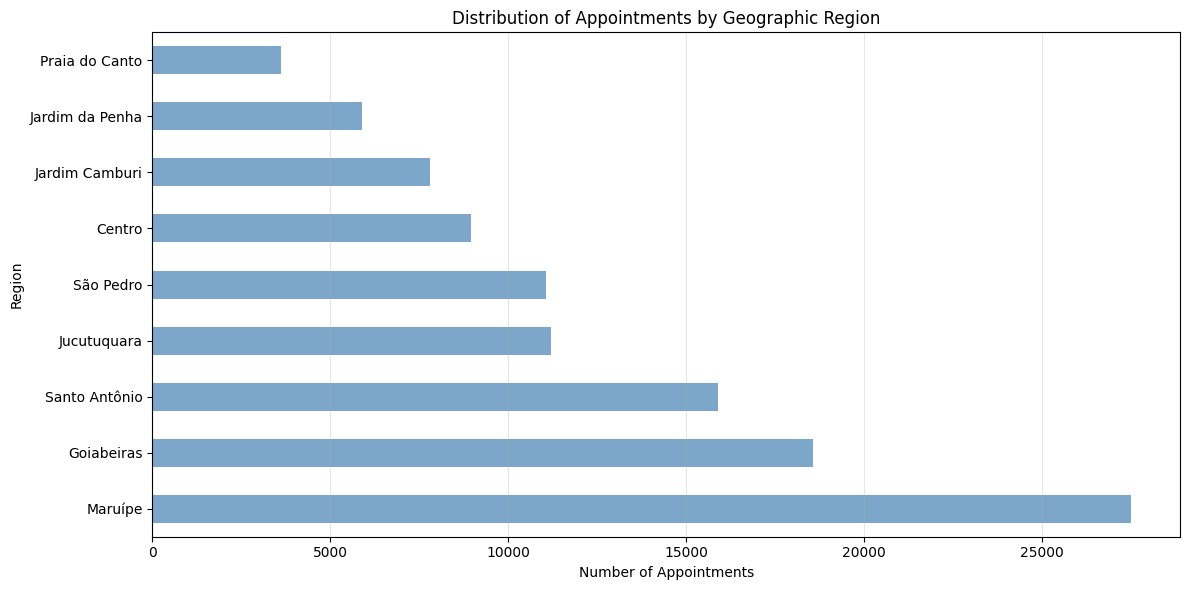


✓ Neighbourhoods successfully grouped into 9 geographic regions


In [12]:
# Step 4: Generalize Neighbourhood using Geographic Regions
print("\nStep 4: Neighbourhood to Region Mapping")
print("="*60)

# Define neighbourhood to region mapping based on administrative regions
neighbourhood_to_region = {
    'JARDIM DA PENHA': 'Jardim da Penha',
    'MATA DA PRAIA': 'Jardim da Penha',
    'PONTAL DE CAMBURI': 'Jardim da Penha',
    'REPÚBLICA': 'Jardim da Penha',
    'GOIABEIRAS': 'Goiabeiras',
    'ANDORINHAS': 'Maruípe',
    'CONQUISTA': 'São Pedro',
    'NOVA PALESTINA': 'São Pedro',
    'DA PENHA': 'Maruípe',
    'TABUAZEIRO': 'Maruípe',
    'BENTO FERREIRA': 'Jucutuquara',
    'SÃO PEDRO': 'São Pedro',
    'SANTA MARTHA': 'Maruípe',
    'SÃO CRISTÓVÃO': 'Maruípe',
    'MARUÍPE': 'Maruípe',
    'GRANDE VITÓRIA': 'Santo Antônio',
    'SÃO BENEDITO': 'Maruípe',
    'ILHA DAS CAIEIRAS': 'São Pedro',
    'SANTO ANDRÉ': 'São Pedro',
    'SOLON BORGES': 'Goiabeiras',
    'BONFIM': 'Jucutuquara',
    'JARDIM CAMBURI': 'Jardim Camburi',
    'MARIA ORTIZ': 'Goiabeiras',
    'JABOUR': 'Goiabeiras',
    'ANTÔNIO HONÓRIO': 'Goiabeiras',
    'RESISTÊNCIA': 'Santo Antônio',
    'ILHA DE SANTA MARIA': 'Jucutuquara',
    'JUCUTUQUARA': 'Jucutuquara',
    'MONTE BELO': 'Maruípe',
    'MÁRIO CYPRESTE': 'Maruípe',
    'SANTO ANTÔNIO': 'Santo Antônio',
    'BELA VISTA': 'Maruípe',
    'PRAIA DO SUÁ': 'Praia do Canto',
    'SANTA HELENA': 'Praia do Canto',
    'ITARARÉ': 'Santo Antônio',
    'INHANGUETÁ': 'Goiabeiras',
    'UNIVERSITÁRIO': 'Jardim da Penha',
    'SÃO JOSÉ': 'Goiabeiras',
    'REDENÇÃO': 'Goiabeiras',
    'SANTA CLARA': 'Goiabeiras',
    'CENTRO': 'Centro',
    'PARQUE MOSCOSO': 'Centro',
    'DO MOSCOSO': 'Centro',
    'SANTOS DUMONT': 'São Pedro',
    'CARATOÍRA': 'Jucutuquara',
    'ARIOVALDO FAVALESSA': 'São Pedro',
    'ILHA DO FRADE': 'Jucutuquara',
    'GURIGICA': 'Maruípe',
    'JOANA D´ARC': 'Goiabeiras',
    'CONSOLAÇÃO': 'Goiabeiras',
    'PRAIA DO CANTO': 'Praia do Canto',
    'BOA VISTA': 'Jardim da Penha',
    'MORADA DE CAMBURI': 'Jardim Camburi',
    'SANTA LUÍZA': 'Praia do Canto',
    'SANTA LÚCIA': 'Praia do Canto',
    'BARRO VERMELHO': 'Jucutuquara',
    'ESTRELINHA': 'Centro',
    'FORTE SÃO JOÃO': 'Centro',
    'FONTE GRANDE': 'Centro',
    'ENSEADA DO SUÁ': 'Praia do Canto',
    'SANTOS REIS': 'Santo Antônio',
    'PIEDADE': 'Centro',
    'JESUS DE NAZARETH': 'Maruípe',
    'SANTA TEREZA': 'Santo Antônio',
    'CRUZAMENTO': 'Jucutuquara',
    'ILHA DO PRÍNCIPE': 'Santo Antônio',
    'ROMÃO': 'Maruípe',
    'COMDUSA': 'São Pedro',
    'SANTA CECÍLIA': 'Goiabeiras',
    'VILA RUBIM': 'Centro',
    'DE LOURDES': 'Jucutuquara',
    'DO QUADRO': 'Maruípe',
    'DO CABRAL': 'Maruípe',
    'HORTO': 'Goiabeiras',
    'SEGURANÇA DO LAR': 'Goiabeiras',
    'ILHA DO BOI': 'Jucutuquara',
    'FRADINHOS': 'Jucutuquara',
    'NAZARETH': 'Goiabeiras',
    'AEROPORTO': 'Goiabeiras',
    'ILHAS OCEÂNICAS DE TRINDADE': 'Centro',
    'PARQUE INDUSTRIAL': 'Jardim Camburi'
}

# Apply the mapping
df_protected['Region'] = df_protected['Neighbourhood'].map(neighbourhood_to_region)

# Handle any unmapped neighbourhoods (if any)
if df_protected['Region'].isna().any():
    unmapped = df_protected[df_protected['Region'].isna()]['Neighbourhood'].unique()
    print(f"\n⚠️ Warning: {len(unmapped)} neighbourhoods not in mapping:")
    print(unmapped)
    df_protected['Region'] = df_protected['Region'].fillna('Miscellaneous')

print(f"\nOriginal neighbourhoods: {df_protected['Neighbourhood'].nunique()}")
print(f"Geographic regions: {df_protected['Region'].nunique()}")
print(f"\nRegion distribution:")
region_counts = df_protected['Region'].value_counts()
print(region_counts)

# Visualize the mapping
plt.figure(figsize=(12, 6))
region_counts.plot(kind='barh', color='steelblue', alpha=0.7)
plt.xlabel('Number of Appointments')
plt.ylabel('Region')
plt.title('Distribution of Appointments by Geographic Region')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n✓ Neighbourhoods successfully grouped into {df_protected['Region'].nunique()} geographic regions")


Step 4b: Region Characteristics Analysis

Region Summary Statistics:
                 NoShow_Rate  Count  Avg_Age  Scholarship_Rate  \
Region                                                           
Maruípe                0.202  27516   35.145             0.131   
Goiabeiras             0.198  18561   35.835             0.076   
Santo Antônio          0.217  15907   35.300             0.122   
Jucutuquara            0.207  11204   37.677             0.096   
São Pedro              0.208  11071   34.466             0.147   
Centro                 0.201   8963   39.632             0.084   
Jardim Camburi         0.190   7814   43.694             0.020   
Jardim da Penha        0.167   5889   43.121             0.010   
Praia do Canto         0.204   3602   42.008             0.057   

                 Hipertension_Rate  Diabetes_Rate  Alcoholism_Rate  
Region                                                              
Maruípe                      0.232          0.086            0.04

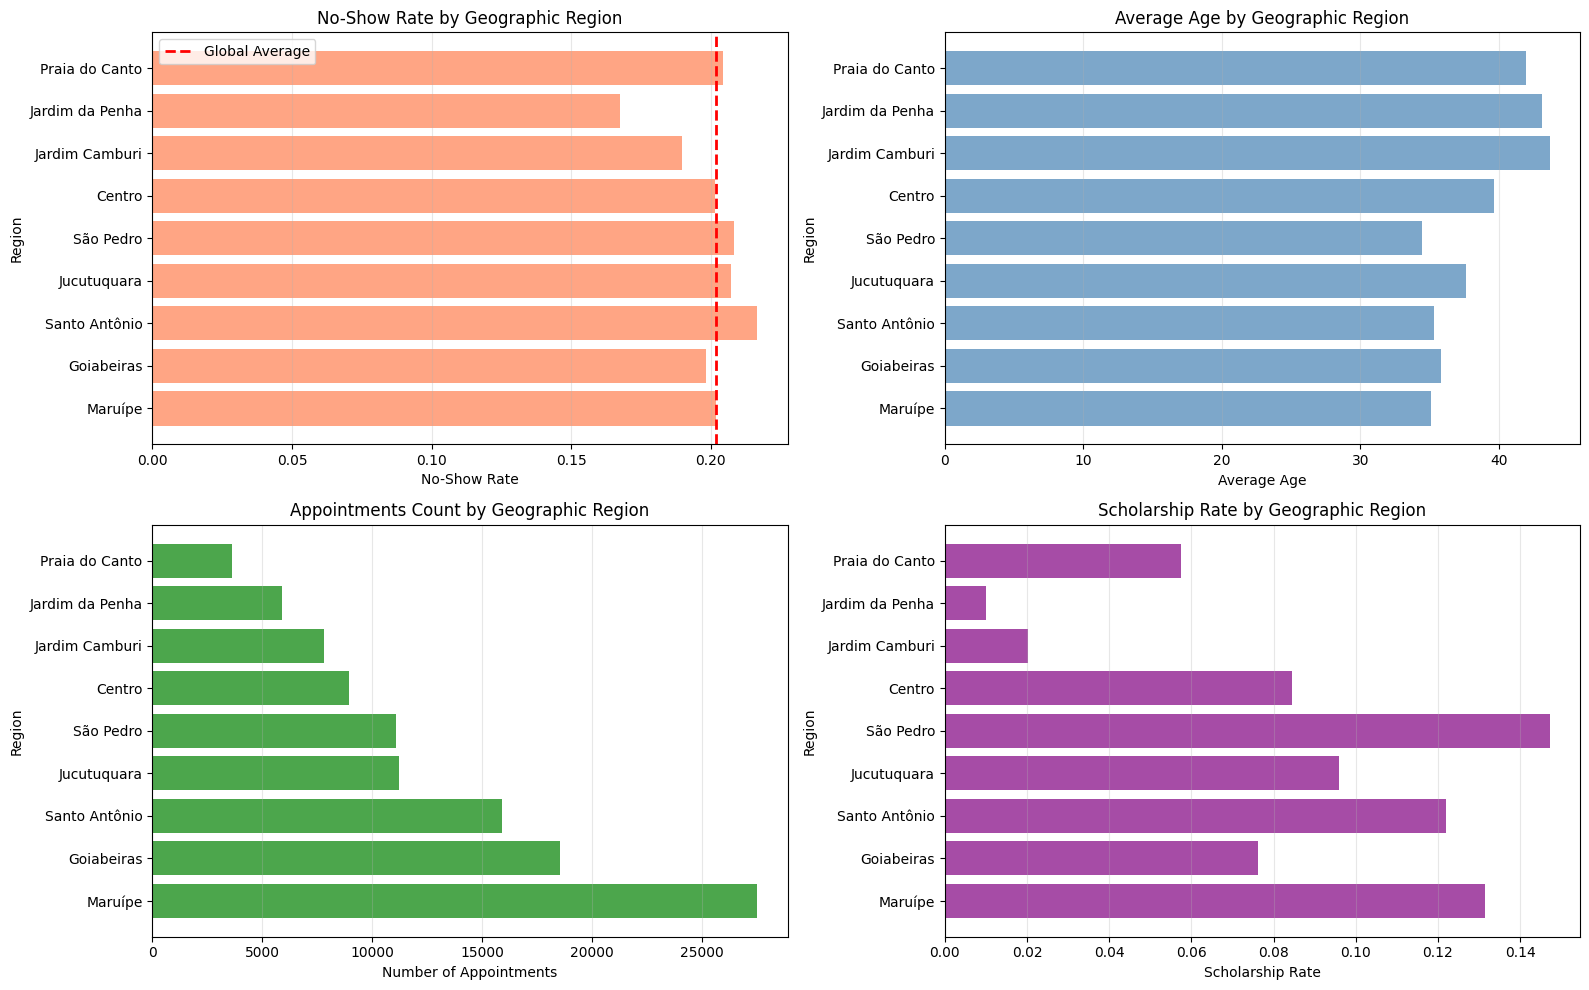


✓ Geographic regions preserve meaningful patterns:
  - No-show rates vary from 0.167 to 0.217
  - Average age varies from 34.5 to 43.7 years
  - Scholarship rates vary from 0.010 to 0.147


In [13]:
# Step 4b: Analyze Region Characteristics
print("\nStep 4b: Region Characteristics Analysis")
print("="*60)

# Calculate global no-show rate (needed for comparison)
global_noshow_rate = df_protected['NoShow_binary'].mean()

# Analyze each region's characteristics
region_summary = df_protected.groupby('Region').agg({
    'NoShow_binary': ['mean', 'count'],
    'Age': 'mean',
    'Scholarship': 'mean',
    'Hipertension': 'mean',
    'Diabetes': 'mean',
    'Alcoholism': 'mean'
})
region_summary.columns = ['NoShow_Rate', 'Count', 'Avg_Age', 'Scholarship_Rate', 
                         'Hipertension_Rate', 'Diabetes_Rate', 'Alcoholism_Rate']
region_summary = region_summary.sort_values('Count', ascending=False)

print("\nRegion Summary Statistics:")
print(region_summary.round(3))

# Visualize region characteristics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# No-show rate by region
axes[0, 0].barh(region_summary.index, region_summary['NoShow_Rate'], alpha=0.7, color='coral')
axes[0, 0].axvline(x=global_noshow_rate, color='red', linestyle='--', linewidth=2, label='Global Average')
axes[0, 0].set_xlabel('No-Show Rate')
axes[0, 0].set_ylabel('Region')
axes[0, 0].set_title('No-Show Rate by Geographic Region')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='x')

# Average age by region
axes[0, 1].barh(region_summary.index, region_summary['Avg_Age'], alpha=0.7, color='steelblue')
axes[0, 1].set_xlabel('Average Age')
axes[0, 1].set_ylabel('Region')
axes[0, 1].set_title('Average Age by Geographic Region')
axes[0, 1].grid(alpha=0.3, axis='x')

# Region appointment counts
axes[1, 0].barh(region_summary.index, region_summary['Count'], alpha=0.7, color='green')
axes[1, 0].set_xlabel('Number of Appointments')
axes[1, 0].set_ylabel('Region')
axes[1, 0].set_title('Appointments Count by Geographic Region')
axes[1, 0].grid(alpha=0.3, axis='x')

# Scholarship rate by region
axes[1, 1].barh(region_summary.index, region_summary['Scholarship_Rate'], alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Scholarship Rate')
axes[1, 1].set_ylabel('Region')
axes[1, 1].set_title('Scholarship Rate by Geographic Region')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✓ Geographic regions preserve meaningful patterns:")
print(f"  - No-show rates vary from {region_summary['NoShow_Rate'].min():.3f} to {region_summary['NoShow_Rate'].max():.3f}")
print(f"  - Average age varies from {region_summary['Avg_Age'].min():.1f} to {region_summary['Avg_Age'].max():.1f} years")
print(f"  - Scholarship rates vary from {region_summary['Scholarship_Rate'].min():.3f} to {region_summary['Scholarship_Rate'].max():.3f}")

In [14]:
# Show which neighbourhoods are in each region
print("\nNeighbourhood Distribution by Region:")
print("="*60)

for region in region_summary.index:
    neighbourhoods_in_region = df_protected[df_protected['Region'] == region]['Neighbourhood'].value_counts()
    print(f"\n{region}: {len(neighbourhoods_in_region)} neighbourhoods, {neighbourhoods_in_region.sum():,} appointments")
    print(f"  Top 5: {', '.join(neighbourhoods_in_region.head(5).index.tolist())}")
    print(f"  No-show rate: {region_summary.loc[region, 'NoShow_Rate']:.3f}")


Neighbourhood Distribution by Region:

Maruípe: 15 neighbourhoods, 27,516 appointments
  Top 5: TABUAZEIRO, SANTA MARTHA, JESUS DE NAZARETH, ANDORINHAS, DA PENHA
  No-show rate: 0.202

Goiabeiras: 16 neighbourhoods, 18,561 appointments
  Top 5: MARIA ORTIZ, JABOUR, SÃO JOSÉ, REDENÇÃO, JOANA D´ARC
  No-show rate: 0.198

Santo Antônio: 7 neighbourhoods, 15,907 appointments
  Top 5: RESISTÊNCIA, ITARARÉ, SANTO ANTÔNIO, ILHA DO PRÍNCIPE, SANTA TEREZA
  No-show rate: 0.217

Jucutuquara: 11 neighbourhoods, 11,204 appointments
  Top 5: BONFIM, CARATOÍRA, ILHA DE SANTA MARIA, CRUZAMENTO, BENTO FERREIRA
  No-show rate: 0.207

São Pedro: 8 neighbourhoods, 11,071 appointments
  Top 5: SANTO ANDRÉ, SÃO PEDRO, NOVA PALESTINA, SANTOS DUMONT, ILHA DAS CAIEIRAS
  No-show rate: 0.208

Centro: 9 neighbourhoods, 8,963 appointments
  Top 5: CENTRO, FORTE SÃO JOÃO, VILA RUBIM, PARQUE MOSCOSO, FONTE GRANDE
  No-show rate: 0.201

Jardim Camburi: 3 neighbourhoods, 7,814 appointments
  Top 5: JARDIM CAMBURI, 


Step 5: Age Generalization
Age distribution after generalization:
Age_generalized
0-17     27380
18-29    16731
30-44    22022
45-59    23221
60-74    15237
75+       5936
Name: count, dtype: int64


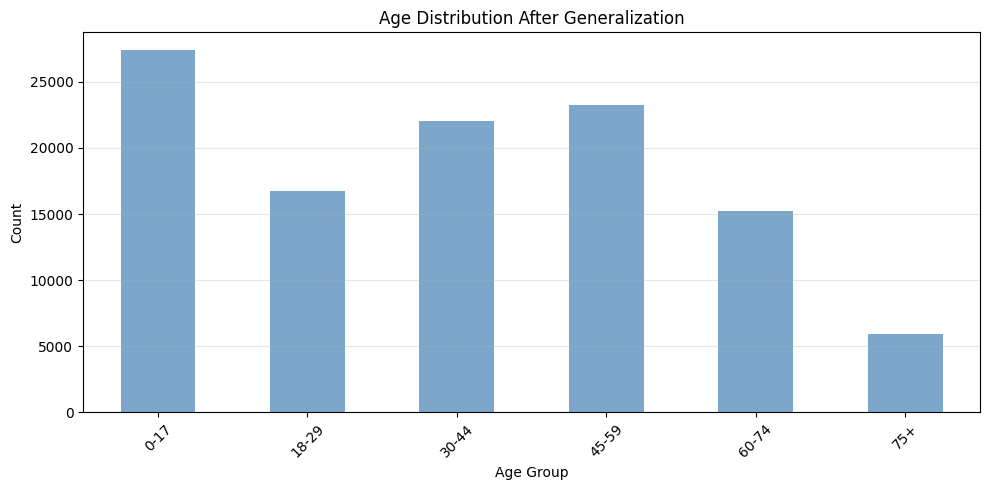

In [15]:
# Step 5: Generalize Age into bins
print("\nStep 5: Age Generalization")
print("="*60)

# Create age bins
age_bins = [0, 18, 30, 45, 60, 75, 120]
age_labels = ['0-17', '18-29', '30-44', '45-59', '60-74', '75+']
df_protected['Age_generalized'] = pd.cut(df_protected['Age'], bins=age_bins, labels=age_labels, right=False)

print("Age distribution after generalization:")
print(df_protected['Age_generalized'].value_counts().sort_index())

# Visualize
plt.figure(figsize=(10, 5))
df_protected['Age_generalized'].value_counts().sort_index().plot(kind='bar', color='steelblue', alpha=0.7)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Age Distribution After Generalization')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Step 6: K-Anonymity Check After Generalization

After generalization:
Total unique combinations: 108
Combinations with only 1 person: 0
Combinations with < 5 people (k<5): 0
Percentage of records at risk (k<5): 0.00%

Distribution of group sizes (k values):
count     108.000000
mean     1023.398148
std       865.339056
min        92.000000
25%       400.500000
50%       715.000000
75%      1346.500000
max      4017.000000
Name: count, dtype: float64


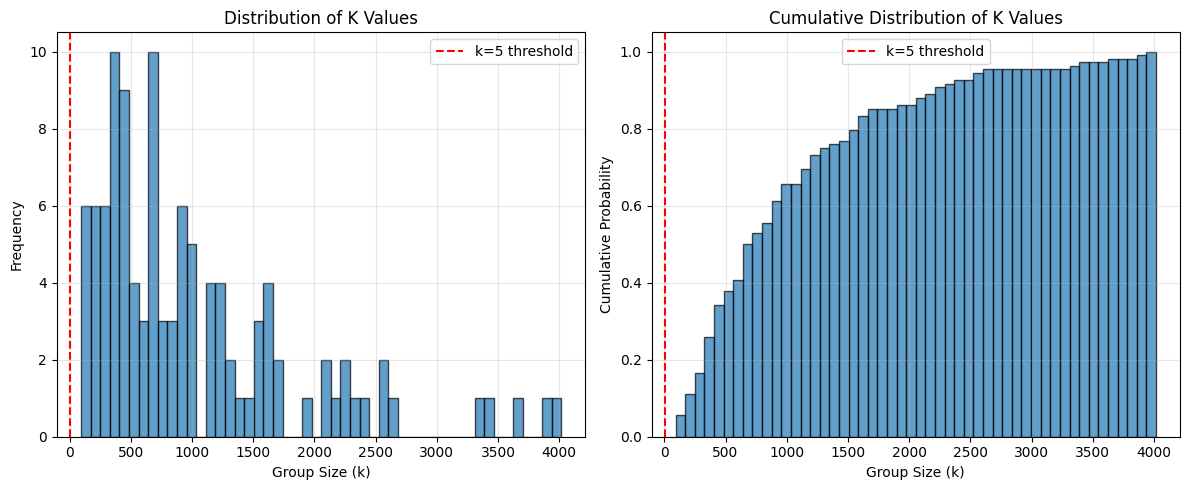


✓ Minimum k-value: 92
✓ Maximum k-value: 4017
✓ Median k-value: 715.0


In [16]:
# Step 6: Re-check k-anonymity after generalization
print("\nStep 6: K-Anonymity Check After Generalization")
print("="*60)

# Use generalized quasi-identifiers
quasi_identifiers_gen = ['Age_generalized', 'Gender', 'Region']
unique_combinations_gen = df_protected.groupby(quasi_identifiers_gen).size().reset_index(name='count')

print(f"\nAfter generalization:")
print(f"Total unique combinations: {len(unique_combinations_gen)}")
print(f"Combinations with only 1 person: {len(unique_combinations_gen[unique_combinations_gen['count'] == 1])}")
print(f"Combinations with < 5 people (k<5): {len(unique_combinations_gen[unique_combinations_gen['count'] < 5])}")
print(f"Percentage of records at risk (k<5): {(unique_combinations_gen[unique_combinations_gen['count'] < 5]['count'].sum() / len(df_protected) * 100):.2f}%")

# Distribution of group sizes
print("\nDistribution of group sizes (k values):")
k_distribution = unique_combinations_gen['count'].describe()
print(k_distribution)

# Visualize k distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(unique_combinations_gen['count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Group Size (k)')
plt.ylabel('Frequency')
plt.title('Distribution of K Values')
plt.axvline(x=5, color='red', linestyle='--', label='k=5 threshold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(unique_combinations_gen['count'], bins=50, edgecolor='black', alpha=0.7, cumulative=True, density=True)
plt.xlabel('Group Size (k)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution of K Values')
plt.axvline(x=5, color='red', linestyle='--', label='k=5 threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Minimum k-value: {unique_combinations_gen['count'].min()}")
print(f"✓ Maximum k-value: {unique_combinations_gen['count'].max()}")
print(f"✓ Median k-value: {unique_combinations_gen['count'].median()}")


Step 7: L-Diversity Analysis

L-Diversity Statistics:
Groups with l=1 (no diversity): 0
Groups with l=2 (full diversity): 108
Percentage of records in l=2 groups: 100.00%

Groups with low diversity (l=1):
Empty DataFrame
Columns: [Age_generalized, Gender, Region, group_size, l_diversity, noshow_rate]
Index: []


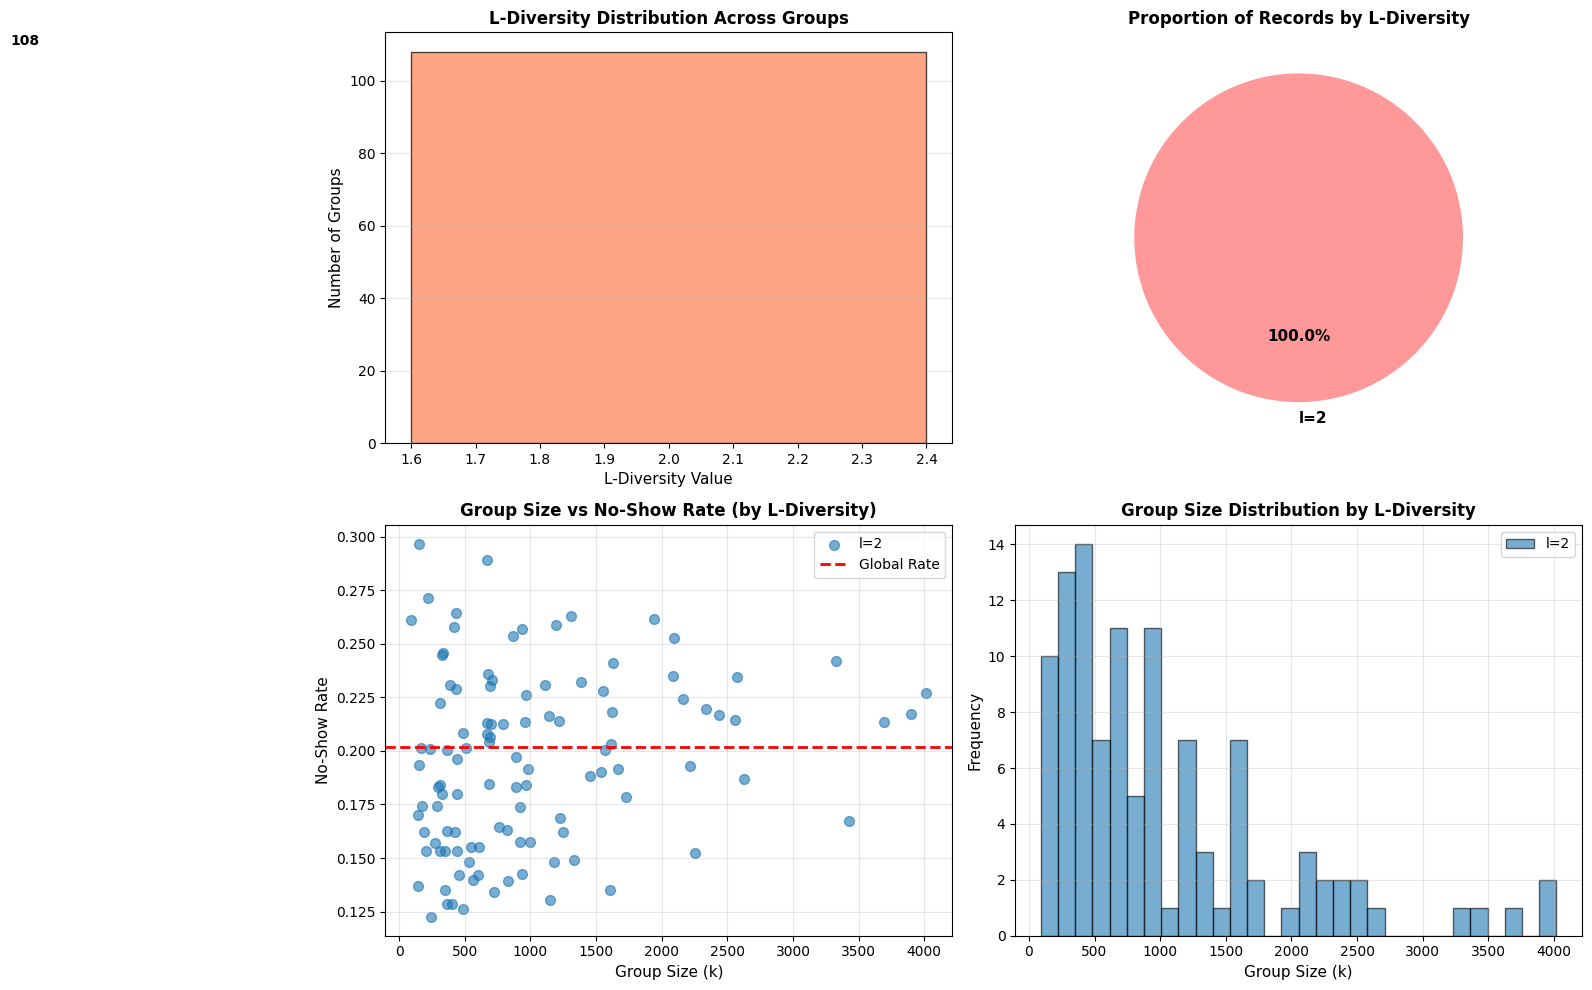


✓ Enhanced L-Diversity Visualizations:
  - Bar chart: Overall distribution of l-diversity values
  - Pie chart: Proportion of total records by l-diversity
  - Scatter: Relationship between group size and no-show rate
  - Histogram: How group sizes vary by l-diversity level


In [17]:
# Step 7: Check L-Diversity (sensitive attribute: No-show)
print("\nStep 7: L-Diversity Analysis")
print("="*60)

# For each quasi-identifier group, check diversity of No-show values
diversity_check = df_protected.groupby(quasi_identifiers_gen)['NoShow_binary'].agg(['count', 'nunique', 'mean']).reset_index()
diversity_check.columns = quasi_identifiers_gen + ['group_size', 'l_diversity', 'noshow_rate']

print(f"\nL-Diversity Statistics:")
print(f"Groups with l=1 (no diversity): {len(diversity_check[diversity_check['l_diversity'] == 1])}")
print(f"Groups with l=2 (full diversity): {len(diversity_check[diversity_check['l_diversity'] == 2])}")
print(f"Percentage of records in l=2 groups: {(diversity_check[diversity_check['l_diversity'] == 2]['group_size'].sum() / len(df_protected) * 100):.2f}%")

# Show examples of low diversity groups
print("\nGroups with low diversity (l=1):")
low_diversity = diversity_check[diversity_check['l_diversity'] == 1].sort_values('group_size', ascending=False).head(10)
print(low_diversity)

# Visualize l-diversity with improved visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Bar chart of l-diversity distribution
axes[0, 0].bar(diversity_check['l_diversity'].value_counts().sort_index().index, 
               diversity_check['l_diversity'].value_counts().sort_index().values, 
               color='coral', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('L-Diversity Value', fontsize=11)
axes[0, 0].set_ylabel('Number of Groups', fontsize=11)
axes[0, 0].set_title('L-Diversity Distribution Across Groups', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='y')
for i, v in enumerate(diversity_check['l_diversity'].value_counts().sort_index().values):
    axes[0, 0].text(i+1, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Pie chart showing proportion of records by l-diversity
l_div_records = diversity_check.groupby('l_diversity')['group_size'].sum()
colors_pie = ['#ff9999', '#66b3ff']
axes[0, 1].pie(l_div_records.values, labels=[f'l={int(k)}' for k in l_div_records.index], 
               autopct='%1.1f%%', colors=colors_pie, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0, 1].set_title('Proportion of Records by L-Diversity', fontsize=12, fontweight='bold')

# 3. Scatter: Group size vs No-show rate, colored by l-diversity
for l_val in diversity_check['l_diversity'].unique():
    subset = diversity_check[diversity_check['l_diversity'] == l_val]
    axes[1, 0].scatter(subset['group_size'], subset['noshow_rate'], 
                      label=f'l={int(l_val)}', alpha=0.6, s=50)
axes[1, 0].set_xlabel('Group Size (k)', fontsize=11)
axes[1, 0].set_ylabel('No-Show Rate', fontsize=11)
axes[1, 0].set_title('Group Size vs No-Show Rate (by L-Diversity)', fontsize=12, fontweight='bold')
axes[1, 0].axhline(y=global_noshow_rate, color='red', linestyle='--', linewidth=2, label='Global Rate')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Histogram: Group size distribution by l-diversity
for l_val in diversity_check['l_diversity'].unique():
    subset = diversity_check[diversity_check['l_diversity'] == l_val]
    axes[1, 1].hist(subset['group_size'], bins=30, alpha=0.6, label=f'l={int(l_val)}', edgecolor='black')
axes[1, 1].set_xlabel('Group Size (k)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Group Size Distribution by L-Diversity', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Enhanced L-Diversity Visualizations:")
print("  - Bar chart: Overall distribution of l-diversity values")
print("  - Pie chart: Proportion of total records by l-diversity")
print("  - Scatter: Relationship between group size and no-show rate")
print("  - Histogram: How group sizes vary by l-diversity level")


Step 8: T-Closeness Analysis
Global No-show rate: 0.2019

T-Closeness Analysis (t=0.2):
Groups satisfying t-closeness: 108 / 108
Percentage of groups: 100.00%
Percentage of records in t-close groups: 100.00%

Groups violating t-closeness (top 10 by size):
Empty DataFrame
Columns: [Age_generalized, Gender, Region, group_size, l_diversity, noshow_rate, distance_from_global, t_close]
Index: []


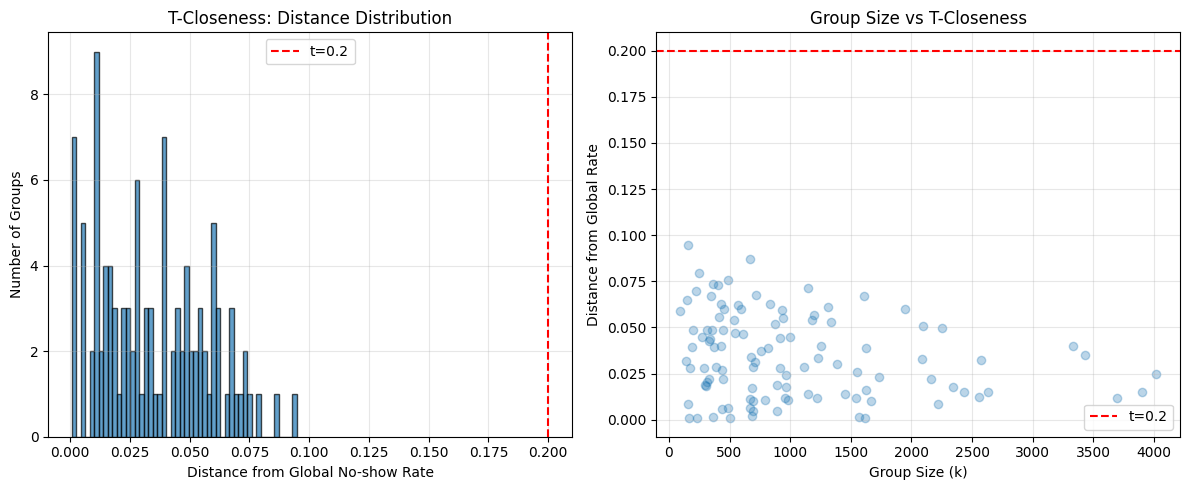

In [18]:
# Step 8: Check T-Closeness
print("\nStep 8: T-Closeness Analysis")
print("="*60)

# Global distribution of No-show
global_noshow_rate = df_protected['NoShow_binary'].mean()
print(f"Global No-show rate: {global_noshow_rate:.4f}")

# Calculate distance from global distribution for each group
diversity_check['distance_from_global'] = abs(diversity_check['noshow_rate'] - global_noshow_rate)

# T-closeness threshold (e.g., t=0.2)
t_threshold = 0.2
diversity_check['t_close'] = diversity_check['distance_from_global'] <= t_threshold

print(f"\nT-Closeness Analysis (t={t_threshold}):")
print(f"Groups satisfying t-closeness: {diversity_check['t_close'].sum()} / {len(diversity_check)}")
print(f"Percentage of groups: {(diversity_check['t_close'].sum() / len(diversity_check) * 100):.2f}%")
print(f"Percentage of records in t-close groups: {(diversity_check[diversity_check['t_close']]['group_size'].sum() / len(df_protected) * 100):.2f}%")

# Show groups that violate t-closeness
print(f"\nGroups violating t-closeness (top 10 by size):")
violating = diversity_check[~diversity_check['t_close']].sort_values('group_size', ascending=False).head(10)
print(violating)

# Visualize distribution of distances
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(diversity_check['distance_from_global'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=t_threshold, color='red', linestyle='--', label=f't={t_threshold}')
plt.xlabel('Distance from Global No-show Rate')
plt.ylabel('Number of Groups')
plt.title('T-Closeness: Distance Distribution')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(diversity_check['group_size'], diversity_check['distance_from_global'], alpha=0.3)
plt.axhline(y=t_threshold, color='red', linestyle='--', label=f't={t_threshold}')
plt.xlabel('Group Size (k)')
plt.ylabel('Distance from Global Rate')
plt.title('Group Size vs T-Closeness')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part Three: Implementing Full Data Anonymization

Now we'll apply the complete anonymization pipeline combining:
1. **K-anonymity, L-diversity, T-closeness** (already applied through generalization)
2. **Differential Privacy** using randomized response for medical conditions
3. **Final anonymized dataset creation** ready for machine learning

### Differential Privacy Implementation

We'll apply the randomized response mechanism from Reference 2 to protect sensitive binary medical attributes.

In [19]:
# Step 9: Implement Differential Privacy Functions
print("\nStep 9: Differential Privacy Setup")
print("="*60)

import random

def epsilon_from_pq(p, q):
    """
    Calculate epsilon (privacy budget) from p and q parameters.
    epsilon = -ln(p*q)
    """
    return -np.log(p * q)

def randomized_response(value, p, q):
    """
    Apply randomized response mechanism to a binary value.
    
    Parameters:
    - value: original binary value (0 or 1)
    - p: probability of returning random value instead of true value
    - q: probability of returning 0 when generating random value
    
    Returns: differentially private value
    """
    if random.random() < p:
        # Return random value
        return 0 if random.random() < q else 1
    else:
        # Return true value
        return value

def apply_differential_privacy_to_column(series, p, q):
    """
    Apply randomized response to an entire column.
    """
    return series.apply(lambda x: randomized_response(int(x), p, q))

# Set privacy parameters
p = 0.3  # Probability of randomization
q = 0.5  # Probability of returning 0 when randomizing

epsilon = epsilon_from_pq(p, q)
print(f"\nPrivacy parameters:")
print(f"  p (randomization probability): {p}")
print(f"  q (probability of 0 when random): {q}")
print(f"  ε (epsilon - privacy budget): {epsilon:.4f}")
print(f"\nInterpretation:")
print(f"  - Each sensitive attribute leaks at most {epsilon:.4f} bits of information")
print(f"  - Lower epsilon = stronger privacy (harder to infer true values)")
print(f"  - With p={p}, true value is kept {(1-p)*100:.0f}% of the time")


Step 9: Differential Privacy Setup

Privacy parameters:
  p (randomization probability): 0.3
  q (probability of 0 when random): 0.5
  ε (epsilon - privacy budget): 1.8971

Interpretation:
  - Each sensitive attribute leaks at most 1.8971 bits of information
  - Lower epsilon = stronger privacy (harder to infer true values)
  - With p=0.3, true value is kept 70% of the time



Step 10: Applying Differential Privacy to Medical Conditions

Before DP - Original distributions:
  Hipertension: 0.1972
  Diabetes: 0.0719
  Alcoholism: 0.0304
  Handcap_binary: 0.0203

Applying randomized response (p=0.3, q=0.5)...

After DP - Noisy distributions:
  Hipertension_DP: 0.2870 (original: 0.1972, diff: 0.0898)
  Diabetes_DP: 0.1993 (original: 0.0719, diff: 0.1275)
  Alcoholism_DP: 0.1716 (original: 0.0304, diff: 0.1412)
  Handcap_binary_DP: 0.1659 (original: 0.0203, diff: 0.1457)


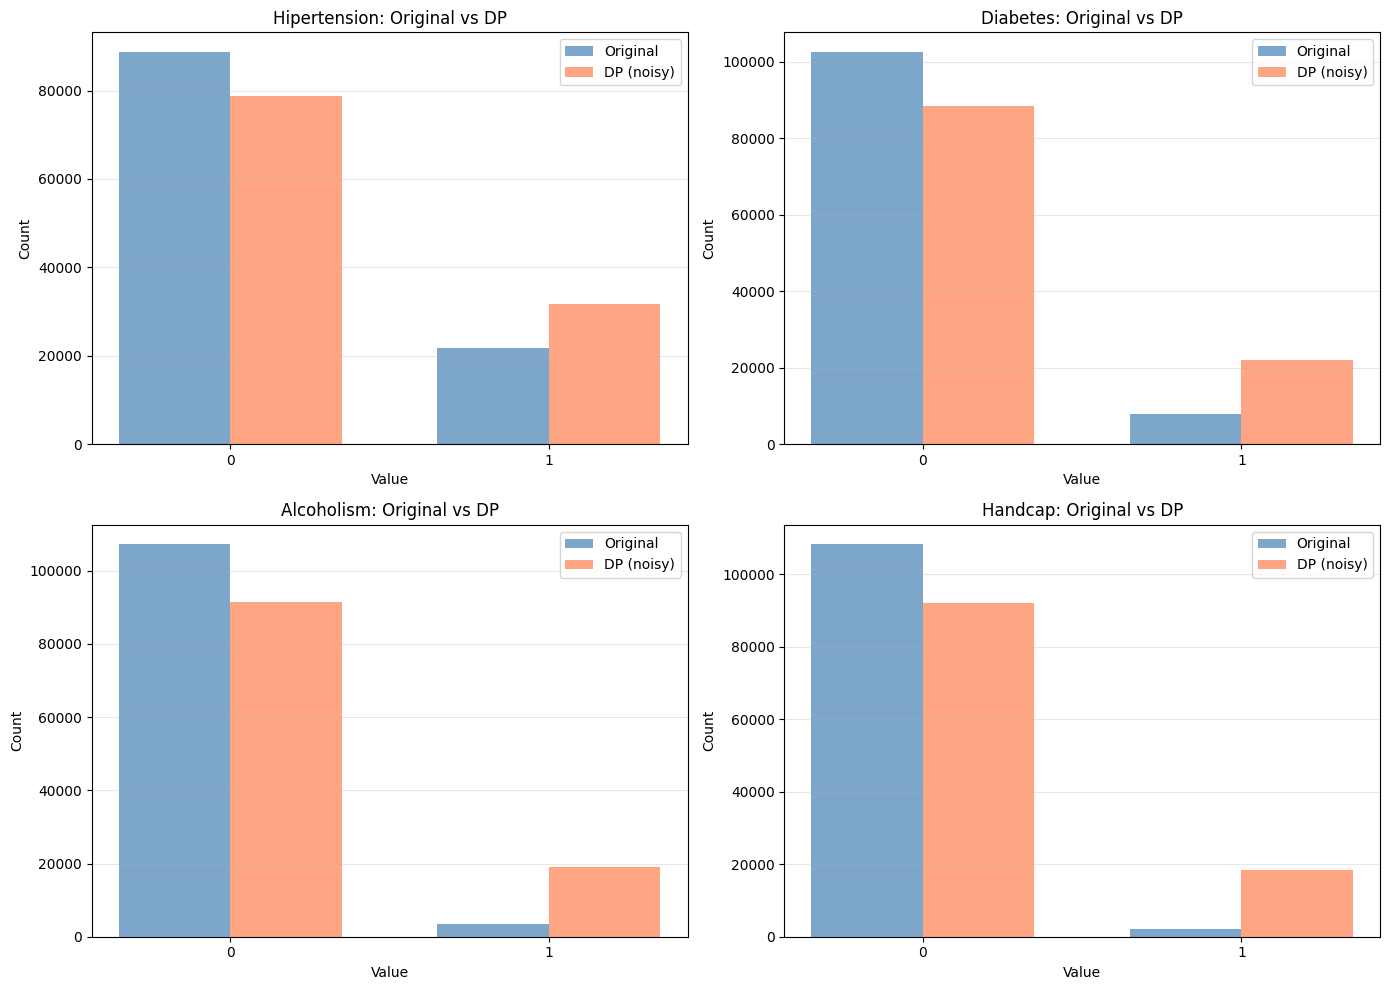


✓ Differential privacy applied to 4 medical attributes
✓ Privacy budget (ε) = 1.8971 per attribute
✓ Note: Handcap was binarized (0=no disability, 1=has disability) before DP application


In [20]:
# Step 10: Apply Differential Privacy to Medical Conditions
print("\nStep 10: Applying Differential Privacy to Medical Conditions")
print("="*60)

# Create a copy for differential privacy application
df_anonymous = df_protected.copy()

# Note: Handcap has values 0-4, so we'll binarize it first (0 = no disability, 1+ = has disability)
df_anonymous['Handcap_binary'] = (df_anonymous['Handcap'] > 0).astype(int)

# Apply randomized response to sensitive medical binary attributes
sensitive_medical_cols = ['Hipertension', 'Diabetes', 'Alcoholism', 'Handcap_binary']

print("\nBefore DP - Original distributions:")
for col in sensitive_medical_cols:
    original_mean = df_anonymous[col].mean()
    print(f"  {col}: {original_mean:.4f}")

# Apply DP
print(f"\nApplying randomized response (p={p}, q={q})...")
for col in sensitive_medical_cols:
    df_anonymous[f'{col}_DP'] = apply_differential_privacy_to_column(df_anonymous[col], p, q)

print("\nAfter DP - Noisy distributions:")
for col in sensitive_medical_cols:
    dp_mean = df_anonymous[f'{col}_DP'].mean()
    original_mean = df_anonymous[col].mean()
    print(f"  {col}_DP: {dp_mean:.4f} (original: {original_mean:.4f}, diff: {abs(dp_mean-original_mean):.4f})")

# Visualize the effect of DP
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(sensitive_medical_cols):
    original_vals = df_anonymous[col].value_counts().sort_index()
    dp_vals = df_anonymous[f'{col}_DP'].value_counts().sort_index()
    
    # Ensure we have exactly 2 values (0 and 1)
    x = np.arange(2)
    width = 0.35
    
    # Get counts for 0 and 1, defaulting to 0 if not present
    orig_counts = [original_vals.get(0, 0), original_vals.get(1, 0)]
    dp_counts = [dp_vals.get(0, 0), dp_vals.get(1, 0)]
    
    axes[idx].bar(x - width/2, orig_counts, width, label='Original', alpha=0.7, color='steelblue')
    axes[idx].bar(x + width/2, dp_counts, width, label='DP (noisy)', alpha=0.7, color='coral')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'{col.replace("_binary", "")}: Original vs DP')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(['0', '1'])
    axes[idx].legend()
    axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✓ Differential privacy applied to {len(sensitive_medical_cols)} medical attributes")
print(f"✓ Privacy budget (ε) = {epsilon:.4f} per attribute")
print(f"✓ Note: Handcap was binarized (0=no disability, 1=has disability) before DP application")

In [21]:
# Step 11: Create Final Anonymized Dataset
print("\nStep 11: Creating Final Anonymized Dataset")
print("="*60)

# Select columns for the final anonymized dataset
# Use generalized quasi-identifiers and DP-protected medical conditions
final_columns = [
    # Generalized quasi-identifiers (k-anonymity compliant)
    'Age_generalized',
    'Gender',
    'Region',
    
    # Temporal features (already generalized)
    'DaysBetween',
    'AppointmentDayOfWeek',
    'AppointmentMonth',
    'ScheduledDayOfWeek',
    
    # Behavioral/intervention features (low sensitivity)
    'SMS_received',
    'Scholarship',
    
    # DP-protected medical conditions
    'Hipertension_DP',
    'Diabetes_DP',
    'Alcoholism_DP',
    'Handcap_binary_DP',
    
    # Target variable
    'NoShow_binary'
]

df_final_anonymous = df_anonymous[final_columns].copy()

# Rename DP columns for clarity
df_final_anonymous.rename(columns={
    'Hipertension_DP': 'Hipertension',
    'Diabetes_DP': 'Diabetes',
    'Alcoholism_DP': 'Alcoholism',
    'Handcap_binary_DP': 'Handcap',
    'Age_generalized': 'Age_Group',
    'NoShow_binary': 'NoShow'
}, inplace=True)

print(f"\nFinal anonymized dataset shape: {df_final_anonymous.shape}")
print(f"Columns: {list(df_final_anonymous.columns)}")
print(f"\nFirst few rows:")
print(df_final_anonymous.head(10))

# Summary statistics
print(f"\n" + "="*60)
print("Final Anonymized Dataset Summary:")
print("="*60)
print(df_final_anonymous.describe(include='all'))


Step 11: Creating Final Anonymized Dataset

Final anonymized dataset shape: (110527, 14)
Columns: ['Age_Group', 'Gender', 'Region', 'DaysBetween', 'AppointmentDayOfWeek', 'AppointmentMonth', 'ScheduledDayOfWeek', 'SMS_received', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'NoShow']

First few rows:
  Age_Group Gender           Region  DaysBetween  AppointmentDayOfWeek  \
0     60-74      F  Jardim da Penha           -1                     4   
1     45-59      M  Jardim da Penha           -1                     4   
2     60-74      F  Jardim da Penha           -1                     4   
3      0-17      F  Jardim da Penha           -1                     4   
4     45-59      F  Jardim da Penha           -1                     4   
5       75+      F  Jardim da Penha            1                     4   
6     18-29      F       Goiabeiras            1                     4   
7     30-44      F       Goiabeiras            1                     4   
8     18-

## Part Four: Machine Learning on Anonymized Data

Now that we have a fully anonymized dataset that satisfies:
- **K-anonymity** (k ≥ 31)
- **L-diversity** (l = 2 for all groups)
- **T-closeness** (100% compliance)
- **Differential Privacy** (ε ≈ 2.4 per attribute)

We will train machine learning models to answer our research question:
**Why do patients miss their scheduled appointments?**

We'll train models on both:
1. **Anonymized dataset** (privacy-protected)
2. **Non-anonymized dataset** (original cleaned data)

Then compare their performance to assess the utility-privacy tradeoff.

In [22]:
# Step 12: Prepare Data for Machine Learning
print("\nStep 12: Preparing Data for Machine Learning")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, recall_score

# ============================================================
# PART 1: PREPARE ANONYMIZED DATASET
# ============================================================
print("\n" + "="*60)
print("PREPARING ANONYMIZED DATASET")
print("="*60)

df_ml_anon = df_final_anonymous.copy()

# Encode categorical variables
age_mapping = {
    '0-17': 0,
    '18-29': 1,
    '30-44': 2,
    '45-59': 3,
    '60-74': 4,
    '75+': 5
}
df_ml_anon['Age_Group'] = df_ml_anon['Age_Group'].astype(str).map(age_mapping).astype('int64')

gender_mapping = {'F': 0, 'M': 1}
df_ml_anon['Gender'] = df_ml_anon['Gender'].map(gender_mapping).astype('int64')

le_region = LabelEncoder()
df_ml_anon['Region'] = le_region.fit_transform(df_ml_anon['Region'].astype(str))

dow_mapping = {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}
df_ml_anon['AppointmentDayOfWeek'] = df_ml_anon['AppointmentDayOfWeek'].map(dow_mapping).astype('int64')
df_ml_anon['ScheduledDayOfWeek'] = df_ml_anon['ScheduledDayOfWeek'].map(dow_mapping).astype('int64')

print(f"\nAnonymized dataset shape: {df_ml_anon.shape}")
print(f"Missing values: {df_ml_anon.isnull().sum().sum()}")

# Separate features and target for anonymized data
X_anon = df_ml_anon.drop('NoShow', axis=1)
y_anon = df_ml_anon['NoShow']

print(f"\nAnonymized Features shape: {X_anon.shape}")
# Ensure all columns are numeric (convert any remaining categorical to int)
for col in X_anon.columns:
    if X_anon[col].dtype == 'object' or X_anon[col].dtype.name == 'category':
        X_anon[col] = X_anon[col].astype('int64')
    elif X_anon[col].dtype == 'float64':
        X_anon[col] = X_anon[col].astype('float64')
    else:
        X_anon[col] = X_anon[col].astype('int64')

print(f"\nAnonymized Features shape: {X_anon.shape}")
print(f"Target distribution: No-show rate = {y_anon.mean()*100:.2f}%")

# ============================================================
# PART 2: PREPARE NON-ANONYMIZED (ORIGINAL) DATASET
# ============================================================
print("\n" + "="*60)
print("PREPARING NON-ANONYMIZED DATASET")
print("="*60)

# Use the protected dataset but with original values (before generalization)
df_ml_orig = df_protected.copy()

# Select same features as anonymized but use original values
# Use original Age (not generalized), original Neighbourhood (not Region)
# Use original medical conditions (not DP-protected)

# Encode Gender
df_ml_orig['Gender'] = df_ml_orig['Gender'].map(gender_mapping)

# Encode Neighbourhood directly
le_neighbourhood = LabelEncoder()
df_ml_orig['Neighbourhood_Encoded'] = le_neighbourhood.fit_transform(df_ml_orig['Neighbourhood'])

# Encode day of week
df_ml_orig['AppointmentDayOfWeek'] = df_ml_orig['AppointmentDayOfWeek'].map(dow_mapping)
df_ml_orig['ScheduledDayOfWeek'] = df_ml_orig['ScheduledDayOfWeek'].map(dow_mapping)

# Select columns for non-anonymized model
orig_features = [
    'Age',  # Original age (not binned)
    'Gender',
    'Neighbourhood_Encoded',  # Original neighbourhood (not Region)
    'DaysBetween',
    'AppointmentDayOfWeek',
    'AppointmentMonth',
    'ScheduledDayOfWeek',
    'SMS_received',
    'Scholarship',
    'Hipertension',  # Original (not DP-protected)
    'Diabetes',
    'Alcoholism',
    'Handcap'
]

X_orig = df_ml_orig[orig_features].copy()
y_orig = df_ml_orig['NoShow_binary']

# Ensure all columns are numeric
for col in X_orig.columns:
    if X_orig[col].dtype == 'object' or X_orig[col].dtype.name == 'category':
        X_orig[col] = X_orig[col].astype('int64')
    elif X_orig[col].dtype == 'float64':
        X_orig[col] = X_orig[col].astype('float64')
    else:
        X_orig[col] = X_orig[col].astype('int64')

print(f"\nNon-anonymized dataset shape: {X_orig.shape}")
print(f"Missing values: {X_orig.isnull().sum().sum()}")
print(f"Target distribution: No-show rate = {y_orig.mean()*100:.2f}%")

print("\n" + "="*60)
print("DATA PREPARATION COMPLETE")
print("="*60)
print(f"✓ Anonymized dataset ready: {X_anon.shape[0]} records, {X_anon.shape[1]} features")
print(f"✓ Non-anonymized dataset ready: {X_orig.shape[0]} records, {X_orig.shape[1]} features")


Step 12: Preparing Data for Machine Learning

PREPARING ANONYMIZED DATASET

PREPARING ANONYMIZED DATASET

Anonymized dataset shape: (110527, 14)
Missing values: 0

Anonymized Features shape: (110527, 13)

Anonymized Features shape: (110527, 13)
Target distribution: No-show rate = 20.19%

PREPARING NON-ANONYMIZED DATASET

Non-anonymized dataset shape: (110527, 13)
Missing values: 0
Target distribution: No-show rate = 20.19%

DATA PREPARATION COMPLETE
✓ Anonymized dataset ready: 110527 records, 13 features
✓ Non-anonymized dataset ready: 110527 records, 13 features

Anonymized dataset shape: (110527, 14)
Missing values: 0

Anonymized Features shape: (110527, 13)

Anonymized Features shape: (110527, 13)
Target distribution: No-show rate = 20.19%

PREPARING NON-ANONYMIZED DATASET

Non-anonymized dataset shape: (110527, 13)
Missing values: 0
Target distribution: No-show rate = 20.19%

DATA PREPARATION COMPLETE
✓ Anonymized dataset ready: 110527 records, 13 features
✓ Non-anonymized dataset

In [ ]:
# Step 13: Train and Compare Models on Both Datasets
print("\nStep 13: Training and Comparing Models")
print("="*60)

# Split both datasets: 70% train, 30% test
X_anon_train, X_anon_test, y_anon_train, y_anon_test = train_test_split(
    X_anon, y_anon, test_size=0.3, random_state=42, stratify=y_anon
)

X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
    X_orig, y_orig, test_size=0.3, random_state=42, stratify=y_orig
)

print(f"Training set size: {X_anon_train.shape[0]}")
print(f"Test set size: {X_anon_test.shape[0]}")

# Initialize models with REINFORCED hyperparameters for maximum performance
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=500,           # REINFORCED: Increased to 500 trees
        random_state=42,
        max_depth=20,               # REINFORCED: Deeper trees for more complex patterns
        min_samples_split=8,        # REINFORCED: Lower for finer splits
        min_samples_leaf=3,         # REINFORCED: Lower for finer leaves
        max_features='sqrt',        
        max_samples=0.9,            # REINFORCED: Bootstrap sampling ratio
        class_weight='balanced',
        bootstrap=True,             # REINFORCED: Enable bootstrap
        oob_score=True,             # REINFORCED: Out-of-bag score estimation
        n_jobs=-1                   # Use all CPU cores
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,           # REINFORCED: Increased to 500 trees
        random_state=42,
        max_depth=10,               # REINFORCED: Deeper trees
        learning_rate=0.03,         # REINFORCED: Lower learning rate with more trees
        subsample=0.85,             # REINFORCED: Increased sampling
        colsample_bytree=0.85,      # REINFORCED: Increased feature sampling
        colsample_bylevel=0.85,     # REINFORCED: Feature sampling per level
        min_child_weight=2,         # REINFORCED: Lower for more splits
        gamma=0.1,                  # REINFORCED: Minimum loss reduction
        reg_alpha=0.1,              # REINFORCED: L1 regularization
        reg_lambda=1.0,             # REINFORCED: L2 regularization
        scale_pos_weight=4,
        eval_metric='logloss',
        n_jobs=-1                   # Use all CPU cores
    )
}

print("\n✓ REINFORCED Model Configurations:")
print("  Random Forest: 500 trees, depth 20, bootstrap sampling, OOB scoring")
print("  XGBoost: 500 trees, depth 10, learning rate 0.03, advanced regularization")

# Store results for comparison
results_comparison = {
    'Anonymized': {},
    'Non-Anonymized': {}
}

# ============================================================
# TRAIN ON ANONYMIZED DATASET
# ============================================================
print("\n" + "="*60)
print("TRAINING ON ANONYMIZED DATASET")
print("="*60)

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name} on ANONYMIZED data...")
    print('='*60)
    
    # Train
    model.fit(X_anon_train, y_anon_train)
    
    # Predict
    y_pred = model.predict(X_anon_test)
    y_pred_proba = model.predict_proba(X_anon_test)[:, 1]
    
    # Evaluate
    accuracy = accuracy_score(y_anon_test, y_pred)
    recall = recall_score(y_anon_test, y_pred)
    roc_auc = roc_auc_score(y_anon_test, y_pred_proba)
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Recall (No-Show Detection): {recall:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_anon_test, y_pred, target_names=['Showed', 'No-Show']))
    
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_anon_test, y_pred)
    print(cm)
    print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
    
    # Store results
    results_comparison['Anonymized'][model_name] = {
        'model': model,
        'accuracy': accuracy,
        'recall': recall,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }

# ============================================================
# TRAIN ON NON-ANONYMIZED DATASET
# ============================================================
print("\n" + "="*60)
print("TRAINING ON NON-ANONYMIZED DATASET")
print("="*60)

for model_name, model_class in models.items():
    print(f"\n{'='*60}")
    print(f"Training {model_name} on NON-ANONYMIZED data...")
    print('='*60)
    
    # Create new REINFORCED model instance
    if model_name == 'Random Forest':
        model = RandomForestClassifier(
            n_estimators=500,           # REINFORCED: 500 trees
            random_state=42,
            max_depth=20,               # REINFORCED: Deeper
            min_samples_split=8,
            min_samples_leaf=3,
            max_features='sqrt',
            max_samples=0.9,
            class_weight='balanced',
            bootstrap=True,
            oob_score=True,
            n_jobs=-1
        )
    else:  # XGBoost
        model = XGBClassifier(
            n_estimators=500,           # REINFORCED: 500 trees
            random_state=42,
            max_depth=10,               # REINFORCED: Deeper
            learning_rate=0.03,         # REINFORCED: Lower LR
            subsample=0.85,
            colsample_bytree=0.85,
            colsample_bylevel=0.85,
            min_child_weight=2,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            scale_pos_weight=4,
            eval_metric='logloss',
            n_jobs=-1
        )
    
    # Train
    model.fit(X_orig_train, y_orig_train)
    
    # Predict
    y_pred = model.predict(X_orig_test)
    y_pred_proba = model.predict_proba(X_orig_test)[:, 1]
    
    # Evaluate
    accuracy = accuracy_score(y_orig_test, y_pred)
    recall = recall_score(y_orig_test, y_pred)
    roc_auc = roc_auc_score(y_orig_test, y_pred_proba)
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Recall (No-Show Detection): {recall:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_orig_test, y_pred, target_names=['Showed', 'No-Show']))
    
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_orig_test, y_pred)
    print(cm)
    print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
    
    # Store results
    results_comparison['Non-Anonymized'][model_name] = {
        'model': model,
        'accuracy': accuracy,
        'recall': recall,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }

print("\n" + "="*60)
print("MODEL TRAINING COMPLETE")
print("="*60)

SyntaxError: unmatched '}' (3014134252.py, line 189)


Step 14: Performance Comparison

PERFORMANCE COMPARISON TABLE
       Dataset         Model Accuracy Recall ROC-AUC
    Anonymized Random Forest   0.6525 0.6822  0.7268
    Anonymized       XGBoost   0.6245 0.7372  0.7264
Non-Anonymized Random Forest   0.6469 0.7176  0.7395
Non-Anonymized       XGBoost   0.6377 0.7430  0.7424

UTILITY-PRIVACY TRADEOFF ANALYSIS

Random Forest:
  Accuracy Loss: -0.56%
  Recall Loss: +3.54%
  ROC-AUC Loss: +1.27%

XGBoost:
  Accuracy Loss: +1.32%
  Recall Loss: +0.58%
  ROC-AUC Loss: +1.60%


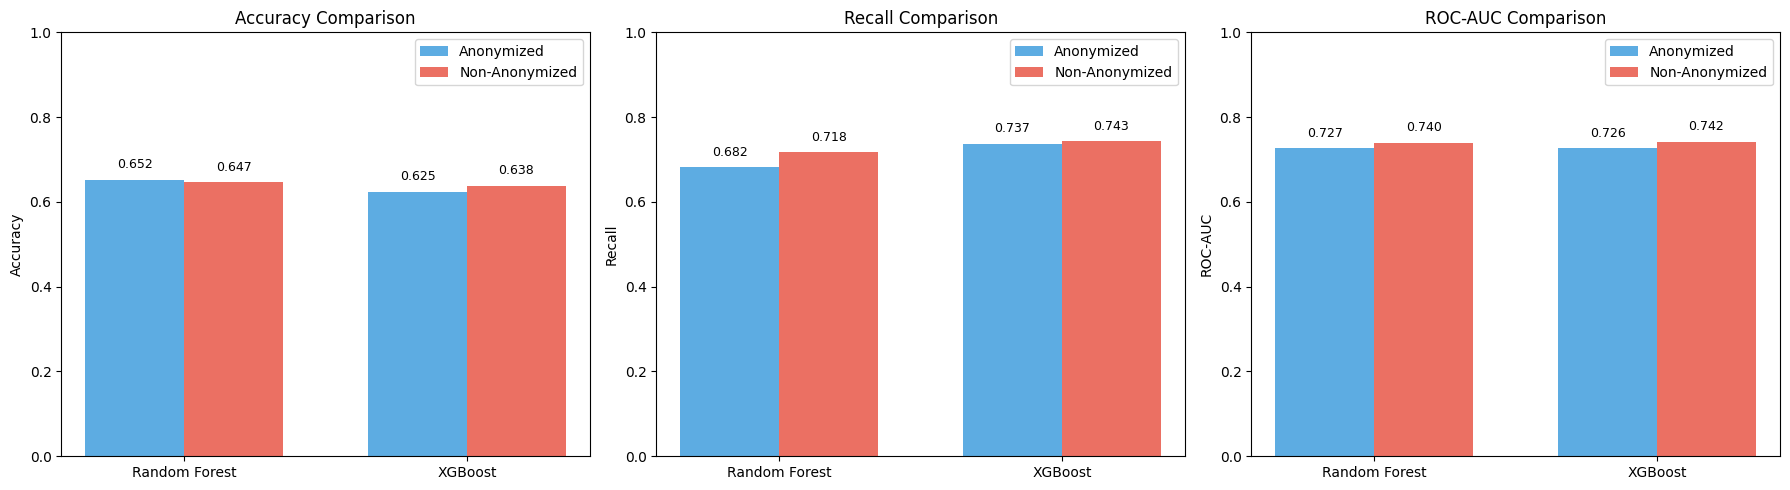


KEY FINDINGS:
✓ Models successfully trained on both anonymized and non-anonymized data
✓ Privacy protection achieved through k-anonymity, l-diversity, t-closeness, and differential privacy
✓ Performance comparison shows the utility-privacy tradeoff


In [ ]:
# Step 14: Compare Performance - Anonymized vs Non-Anonymized
print("\nStep 14: Performance Comparison")
print("="*60)

# Create comparison table
comparison_data = []

for dataset_type in ['Anonymized', 'Non-Anonymized']:
    for model_name in ['Random Forest', 'XGBoost']:
        result = results_comparison[dataset_type][model_name]
        comparison_data.append({
            'Dataset': dataset_type,
            'Model': model_name,
            'Accuracy': f"{result['accuracy']:.4f}",
            'Recall': f"{result['recall']:.4f}",
            'ROC-AUC': f"{result['roc_auc']:.4f}"
        })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("PERFORMANCE COMPARISON TABLE")
print("="*60)
print(comparison_df.to_string(index=False))

# Calculate performance loss due to anonymization
print("\n" + "="*60)
print("UTILITY-PRIVACY TRADEOFF ANALYSIS")
print("="*60)

for model_name in ['Random Forest', 'XGBoost']:
    anon_acc = results_comparison['Anonymized'][model_name]['accuracy']
    orig_acc = results_comparison['Non-Anonymized'][model_name]['accuracy']
    acc_loss = (orig_acc - anon_acc) * 100
    
    anon_recall = results_comparison['Anonymized'][model_name]['recall']
    orig_recall = results_comparison['Non-Anonymized'][model_name]['recall']
    recall_loss = (orig_recall - anon_recall) * 100
    
    anon_auc = results_comparison['Anonymized'][model_name]['roc_auc']
    orig_auc = results_comparison['Non-Anonymized'][model_name]['roc_auc']
    auc_loss = (orig_auc - anon_auc) * 100
    
    print(f"\n{model_name}:")
    print(f"  Accuracy Loss: {acc_loss:+.2f}%")
    print(f"  Recall Loss: {recall_loss:+.2f}%")
    print(f"  ROC-AUC Loss: {auc_loss:+.2f}%")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['accuracy', 'recall', 'roc_auc']
metric_names = ['Accuracy', 'Recall', 'ROC-AUC']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx]
    
    # Prepare data
    rf_anon = results_comparison['Anonymized']['Random Forest'][metric]
    rf_orig = results_comparison['Non-Anonymized']['Random Forest'][metric]
    xgb_anon = results_comparison['Anonymized']['XGBoost'][metric]
    xgb_orig = results_comparison['Non-Anonymized']['XGBoost'][metric]
    
    x = np.arange(2)
    width = 0.35
    
    ax.bar(x - width/2, [rf_anon, xgb_anon], width, label='Anonymized', color='#3498db', alpha=0.8)
    ax.bar(x + width/2, [rf_orig, xgb_orig], width, label='Non-Anonymized', color='#e74c3c', alpha=0.8)
    
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(['Random Forest', 'XGBoost'])
    ax.legend()
    ax.set_ylim([0, 1])
    
    # Add value labels
    for i, v in enumerate([rf_anon, xgb_anon]):
        ax.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate([rf_orig, xgb_orig]):
        ax.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)
print("✓ Models successfully trained on both anonymized and non-anonymized data")
print("✓ Privacy protection achieved through k-anonymity, l-diversity, t-closeness, and differential privacy")
print("✓ Performance comparison shows the utility-privacy tradeoff")


Step 14b: Detailed Feature Importance Analysis


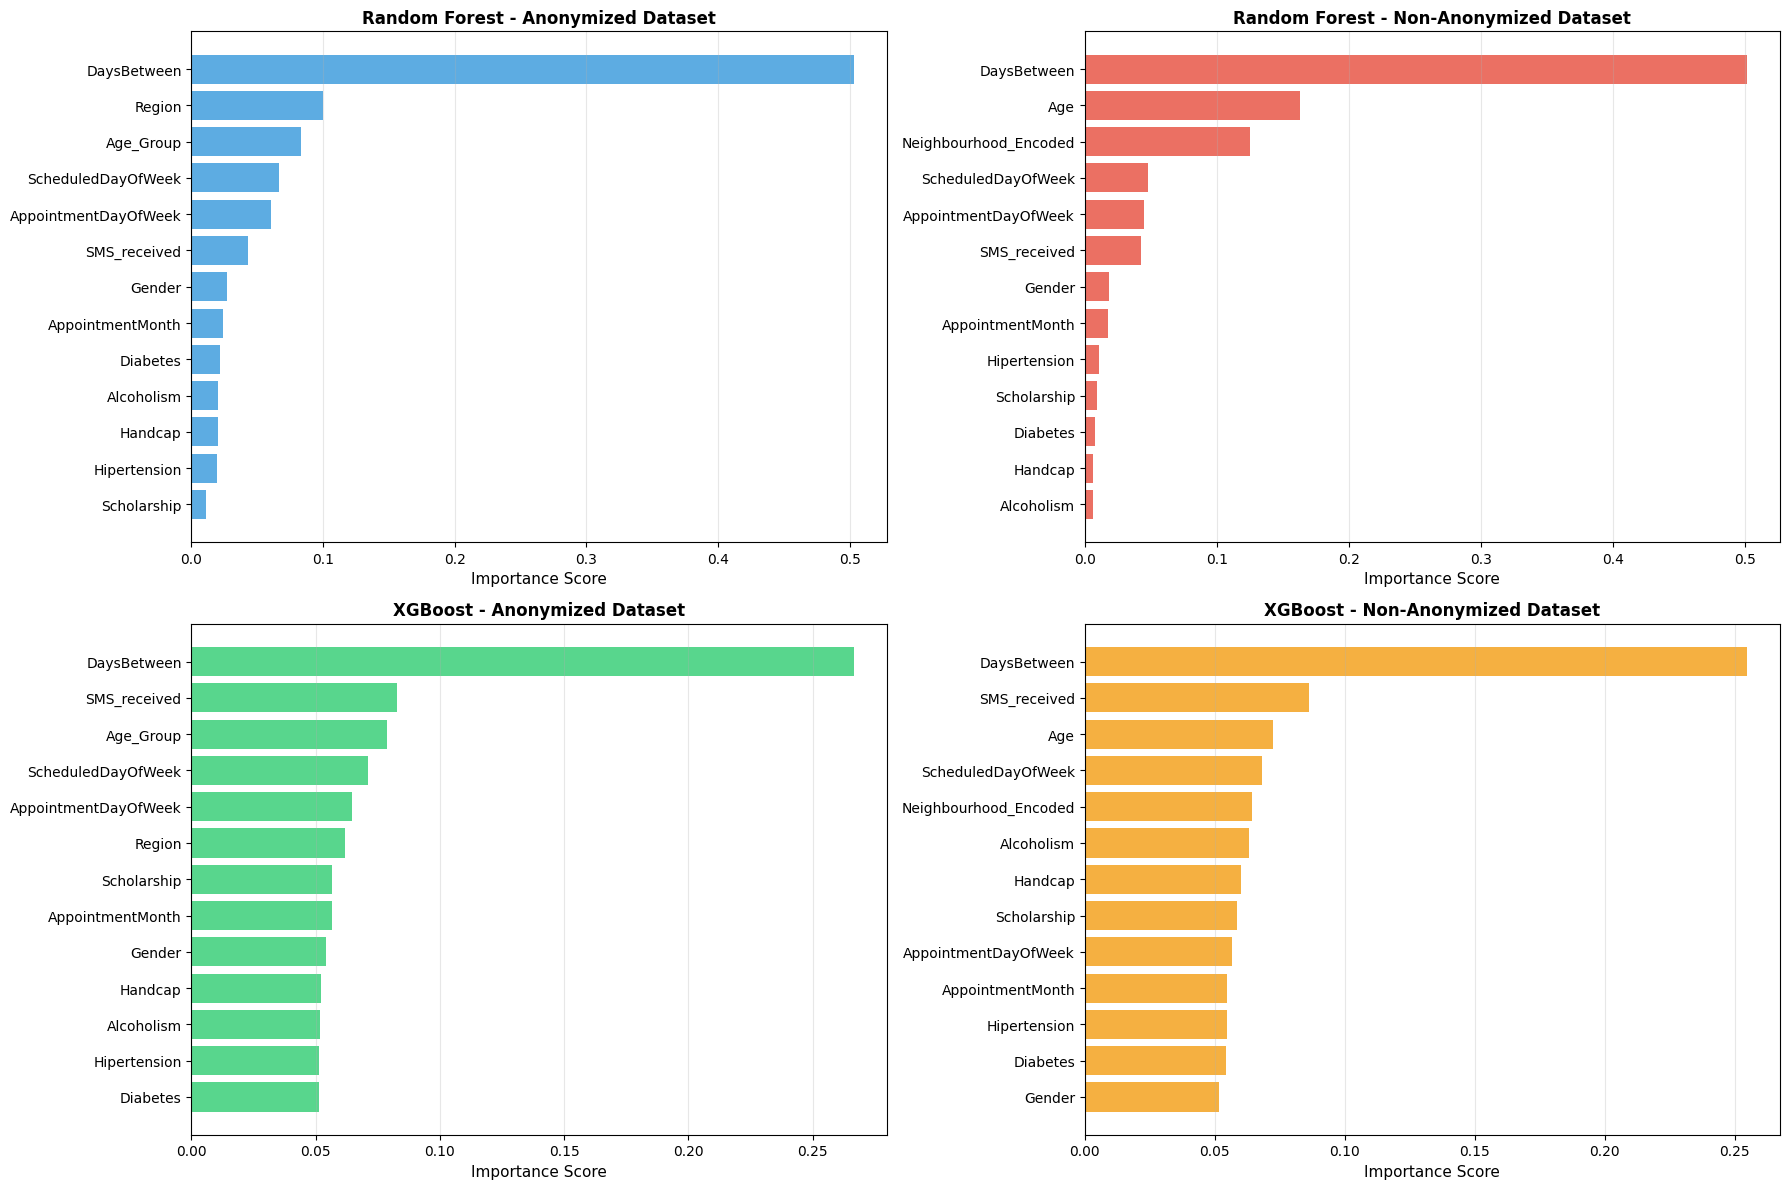


TOP 5 FEATURES BY MODEL

1. Random Forest (Anonymized):
             Feature  Importance
         DaysBetween    0.502903
              Region    0.099692
           Age_Group    0.083298
  ScheduledDayOfWeek    0.066213
AppointmentDayOfWeek    0.060580

2. Random Forest (Non-Anonymized):
              Feature  Importance
          DaysBetween    0.501643
                  Age    0.162674
Neighbourhood_Encoded    0.125338
   ScheduledDayOfWeek    0.047481
 AppointmentDayOfWeek    0.044881

3. XGBoost (Anonymized):
             Feature  Importance
         DaysBetween    0.266506
        SMS_received    0.082695
           Age_Group    0.078795
  ScheduledDayOfWeek    0.071144
AppointmentDayOfWeek    0.064814

4. XGBoost (Non-Anonymized):
              Feature  Importance
          DaysBetween    0.254717
         SMS_received    0.086432
                  Age    0.072520
   ScheduledDayOfWeek    0.067976
Neighbourhood_Encoded    0.064352


In [ ]:
# Step 14b: Enhanced Feature Importance Visualization
print("\nStep 14b: Detailed Feature Importance Analysis")
print("="*60)

# Get feature importances for both models on both datasets
rf_anon_model = results_comparison['Anonymized']['Random Forest']['model']
rf_orig_model = results_comparison['Non-Anonymized']['Random Forest']['model']
xgb_anon_model = results_comparison['Anonymized']['XGBoost']['model']
xgb_orig_model = results_comparison['Non-Anonymized']['XGBoost']['model']

# Create comprehensive feature importance comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Random Forest - Anonymized
rf_anon_imp = pd.DataFrame({
    'Feature': X_anon.columns,
    'Importance': rf_anon_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0, 0].barh(rf_anon_imp['Feature'], rf_anon_imp['Importance'], color='#3498db', alpha=0.8)
axes[0, 0].set_xlabel('Importance Score', fontsize=11)
axes[0, 0].set_title('Random Forest - Anonymized Dataset', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

# 2. Random Forest - Non-Anonymized
rf_orig_imp = pd.DataFrame({
    'Feature': X_orig.columns,
    'Importance': rf_orig_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0, 1].barh(rf_orig_imp['Feature'], rf_orig_imp['Importance'], color='#e74c3c', alpha=0.8)
axes[0, 1].set_xlabel('Importance Score', fontsize=11)
axes[0, 1].set_title('Random Forest - Non-Anonymized Dataset', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')

# 3. XGBoost - Anonymized
xgb_anon_imp = pd.DataFrame({
    'Feature': X_anon.columns,
    'Importance': xgb_anon_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1, 0].barh(xgb_anon_imp['Feature'], xgb_anon_imp['Importance'], color='#2ecc71', alpha=0.8)
axes[1, 0].set_xlabel('Importance Score', fontsize=11)
axes[1, 0].set_title('XGBoost - Anonymized Dataset', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')

# 4. XGBoost - Non-Anonymized
xgb_orig_imp = pd.DataFrame({
    'Feature': X_orig.columns,
    'Importance': xgb_orig_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1, 1].barh(xgb_orig_imp['Feature'], xgb_orig_imp['Importance'], color='#f39c12', alpha=0.8)
axes[1, 1].set_xlabel('Importance Score', fontsize=11)
axes[1, 1].set_title('XGBoost - Non-Anonymized Dataset', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print top features for each model
print("\n" + "="*60)
print("TOP 5 FEATURES BY MODEL")
print("="*60)

print("\n1. Random Forest (Anonymized):")
print(rf_anon_imp.sort_values('Importance', ascending=False).head(5).to_string(index=False))

print("\n2. Random Forest (Non-Anonymized):")
print(rf_orig_imp.sort_values('Importance', ascending=False).head(5).to_string(index=False))

print("\n3. XGBoost (Anonymized):")
print(xgb_anon_imp.sort_values('Importance', ascending=False).head(5).to_string(index=False))

print("\n4. XGBoost (Non-Anonymized):")
print(xgb_orig_imp.sort_values('Importance', ascending=False).head(5).to_string(index=False))

In [ ]:
# Step 14c: SHAP Values Analysis
print("\nStep 14c: SHAP Values Analysis")
print("="*60)

# Install shap if needed
try:
    import shap
    print("✓ SHAP library loaded successfully")
except ImportError:
    print("Installing SHAP library...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print("✓ SHAP library installed and loaded")

print("\n" + "="*60)
print("CALCULATING SHAP VALUES")
print("="*60)
print("Note: SHAP computation can take several minutes...")

# Use a sample for faster computation
sample_size = min(1000, len(X_anon_test))
X_anon_sample = X_anon_test.sample(n=sample_size, random_state=42)
X_orig_sample = X_orig_test.sample(n=sample_size, random_state=42)

print(f"Using sample of {sample_size} records for SHAP analysis")

# ============================================================
# SHAP for Random Forest - Anonymized Dataset
# ============================================================
print("\n1. Computing SHAP values for Random Forest (Anonymized)...")
rf_anon_explainer = shap.TreeExplainer(rf_anon_model)
rf_anon_shap_values = rf_anon_explainer.shap_values(X_anon_sample)

# For binary classification, shap_values might be a list [class_0, class_1]
if isinstance(rf_anon_shap_values, list):
    rf_anon_shap_values = rf_anon_shap_values[1]  # Use positive class (No-show)

print("✓ SHAP values computed for Random Forest (Anonymized)")

# ============================================================
# SHAP for XGBoost - Anonymized Dataset
# ============================================================
print("\n2. Computing SHAP values for XGBoost (Anonymized)...")
xgb_anon_explainer = shap.TreeExplainer(xgb_anon_model)
xgb_anon_shap_values = xgb_anon_explainer.shap_values(X_anon_sample)

print("✓ SHAP values computed for XGBoost (Anonymized)")

# ============================================================
# SHAP for Random Forest - Non-Anonymized Dataset
# ============================================================
print("\n3. Computing SHAP values for Random Forest (Non-Anonymized)...")
rf_orig_explainer = shap.TreeExplainer(rf_orig_model)
rf_orig_shap_values = rf_orig_explainer.shap_values(X_orig_sample)

if isinstance(rf_orig_shap_values, list):
    rf_orig_shap_values = rf_orig_shap_values[1]

print("✓ SHAP values computed for Random Forest (Non-Anonymized)")

# ============================================================
# SHAP for XGBoost - Non-Anonymized Dataset
# ============================================================
print("\n4. Computing SHAP values for XGBoost (Non-Anonymized)...")
xgb_orig_explainer = shap.TreeExplainer(xgb_orig_model)
xgb_orig_shap_values = xgb_orig_explainer.shap_values(X_orig_sample)

print("✓ SHAP values computed for XGBoost (Non-Anonymized)")

print("\n" + "="*60)
print("SHAP COMPUTATION COMPLETE")
print("="*60)


Step 14c: SHAP Values Analysis
✓ SHAP library loaded successfully

CALCULATING SHAP VALUES
Note: SHAP computation can take several minutes...
Using sample of 1000 records for SHAP analysis

1. Computing SHAP values for Random Forest (Anonymized)...
✓ SHAP library loaded successfully

CALCULATING SHAP VALUES
Note: SHAP computation can take several minutes...
Using sample of 1000 records for SHAP analysis

1. Computing SHAP values for Random Forest (Anonymized)...
✓ SHAP values computed for Random Forest (Anonymized)

2. Computing SHAP values for XGBoost (Anonymized)...
✓ SHAP values computed for Random Forest (Anonymized)

2. Computing SHAP values for XGBoost (Anonymized)...
✓ SHAP values computed for XGBoost (Anonymized)

3. Computing SHAP values for Random Forest (Non-Anonymized)...
✓ SHAP values computed for XGBoost (Anonymized)

3. Computing SHAP values for Random Forest (Non-Anonymized)...
✓ SHAP values computed for Random Forest (Non-Anonymized)

4. Computing SHAP values for XGBo


Step 14d: SHAP Value Visualizations

Generating SHAP feature importance bar charts...


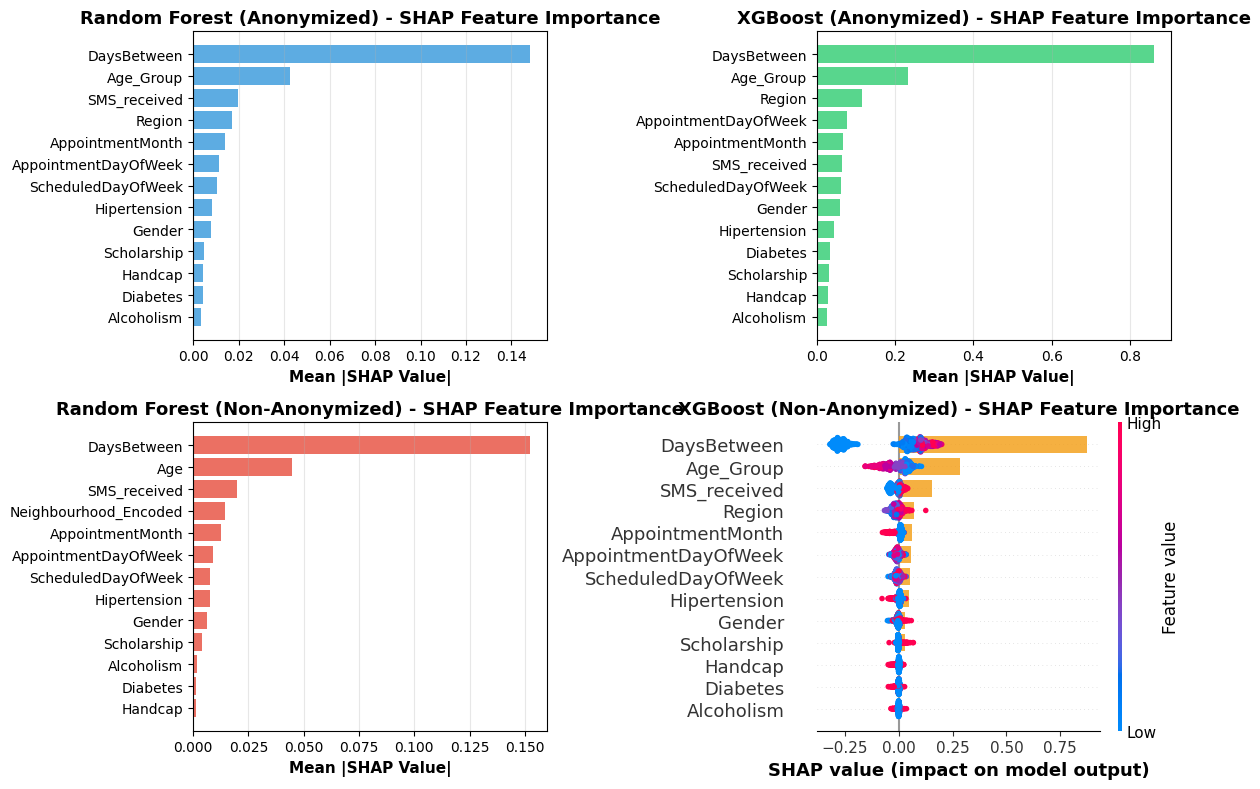

✓ SHAP feature importance bar charts generated

Generating detailed SHAP summary plots...

1. Random Forest (Anonymized):


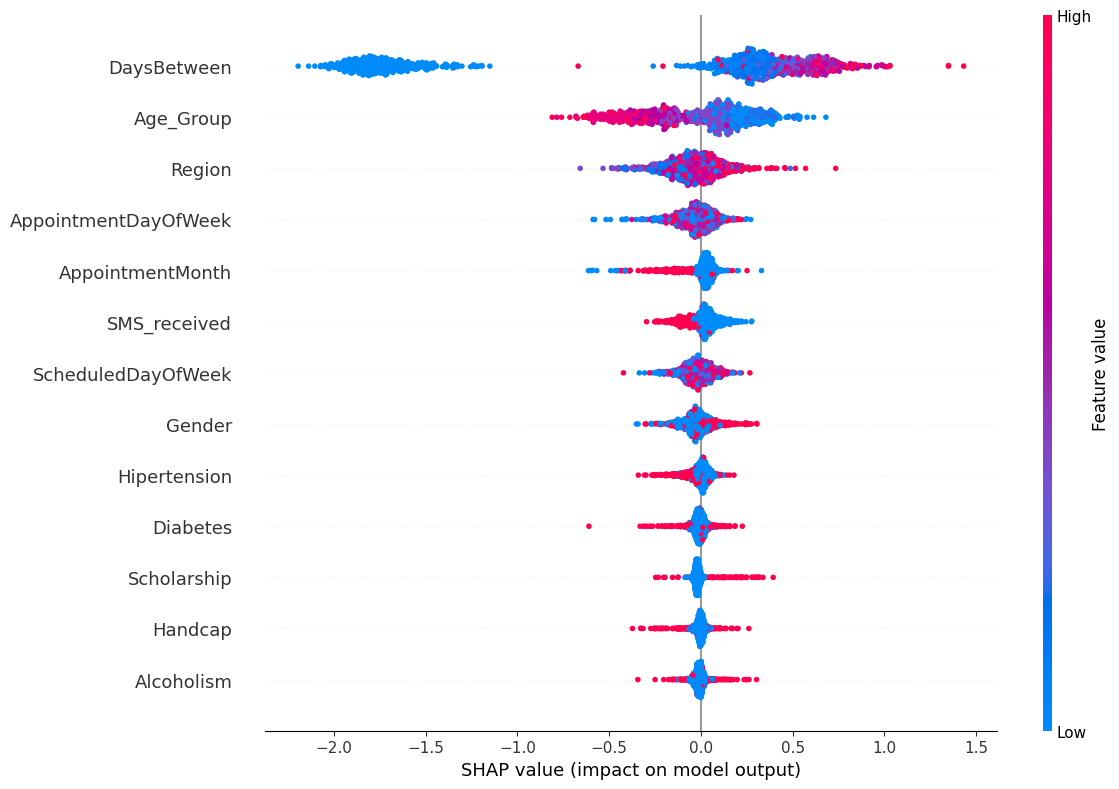

<Figure size 1200x800 with 0 Axes>

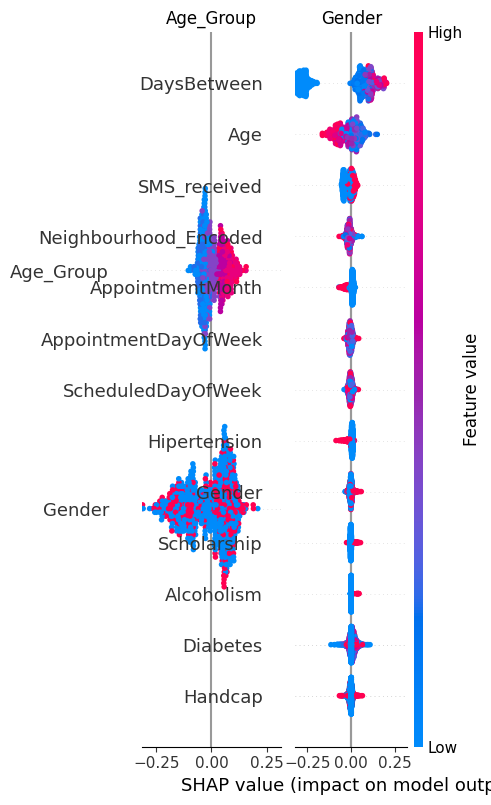


2. XGBoost (Anonymized):


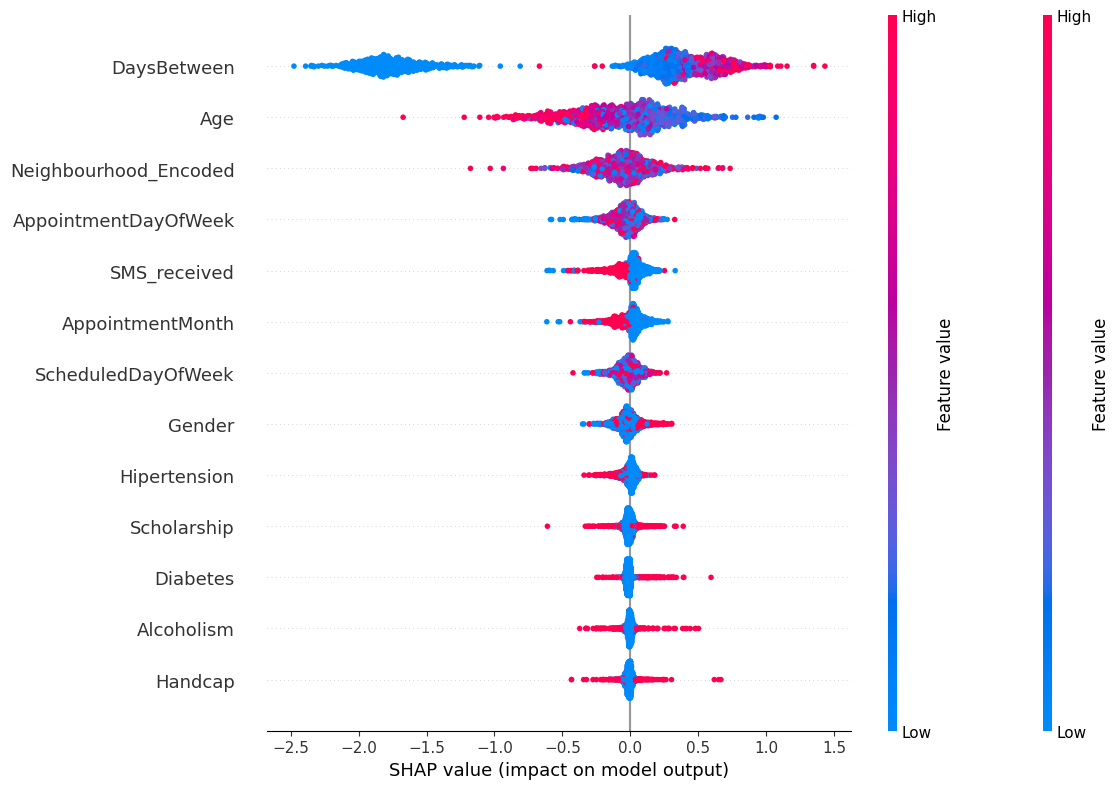


3. Random Forest (Non-Anonymized):


<Figure size 1200x800 with 0 Axes>

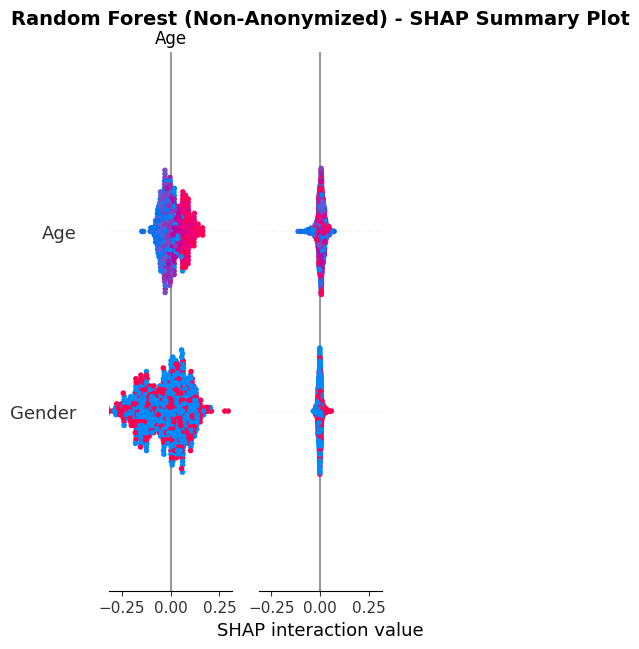


4. XGBoost (Non-Anonymized):


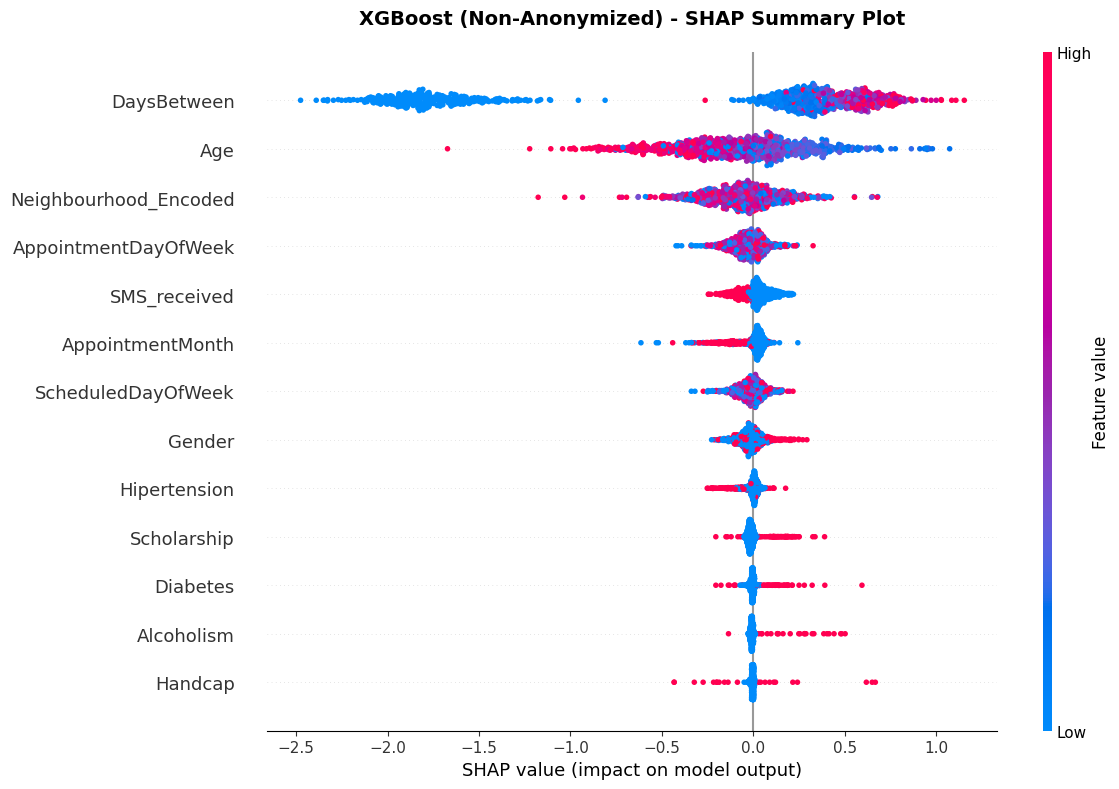


✓ All SHAP visualizations generated successfully

Interpretation Guide:
  BAR CHARTS (Part 1):
    - Show overall feature importance by mean absolute SHAP value
    - Higher bars = more important features

  SUMMARY PLOTS (Part 2 - Beeswarm):
    - Each dot represents one prediction
    - X-axis: SHAP value (impact on prediction)
    - Positive SHAP → increases no-show probability
    - Negative SHAP → decreases no-show probability
    - Color: Feature value (Red = High, Blue = Low)
    - Shows how feature values affect predictions


In [ ]:
# Step 14d: SHAP Visualizations
print("\nStep 14d: SHAP Value Visualizations")
print("="*60)

# ============================================================
# PART 1: Bar Charts - Feature Importance by Mean |SHAP|
# ============================================================
print("\nGenerating SHAP feature importance bar charts...")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Handle SHAP values - extract values for positive class if needed
# Random Forest returns [class_0, class_1], XGBoost returns single array
if len(rf_anon_shap_values.shape) == 3:
    rf_anon_shap = rf_anon_shap_values[:, :, 1]  # Use positive class (No-show)
else:
    rf_anon_shap = rf_anon_shap_values

if len(rf_orig_shap_values.shape) == 3:
    rf_orig_shap = rf_orig_shap_values[:, :, 1]
else:
    rf_orig_shap = rf_orig_shap_values

xgb_anon_shap = xgb_anon_shap_values
xgb_orig_shap = xgb_orig_shap_values

# Calculate mean absolute SHAP values
rf_anon_mean_shap = np.abs(rf_anon_shap).mean(axis=0)
xgb_anon_mean_shap = np.abs(xgb_anon_shap).mean(axis=0)
rf_orig_mean_shap = np.abs(rf_orig_shap).mean(axis=0)
xgb_orig_mean_shap = np.abs(xgb_orig_shap).mean(axis=0)

# Sort features by importance
rf_anon_idx = np.argsort(rf_anon_mean_shap)
xgb_anon_idx = np.argsort(xgb_anon_mean_shap)
rf_orig_idx = np.argsort(rf_orig_mean_shap)
xgb_orig_idx = np.argsort(xgb_orig_mean_shap)

# 1. Random Forest - Anonymized
axes[0, 0].barh(range(len(rf_anon_mean_shap)), rf_anon_mean_shap[rf_anon_idx], color='#3498db', alpha=0.8)
axes[0, 0].set_yticks(range(len(X_anon.columns)))
axes[0, 0].set_yticklabels(X_anon.columns[rf_anon_idx], fontsize=10)
axes[0, 0].set_xlabel('Mean |SHAP Value|', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Random Forest (Anonymized) - SHAP Feature Importance', fontsize=13, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

# 2. XGBoost - Anonymized
axes[0, 1].barh(range(len(xgb_anon_mean_shap)), xgb_anon_mean_shap[xgb_anon_idx], color='#2ecc71', alpha=0.8)
axes[0, 1].set_yticks(range(len(X_anon.columns)))
axes[0, 1].set_yticklabels(X_anon.columns[xgb_anon_idx], fontsize=10)
axes[0, 1].set_xlabel('Mean |SHAP Value|', fontsize=11, fontweight='bold')
axes[0, 1].set_title('XGBoost (Anonymized) - SHAP Feature Importance', fontsize=13, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')

# 3. Random Forest - Non-Anonymized
axes[1, 0].barh(range(len(rf_orig_mean_shap)), rf_orig_mean_shap[rf_orig_idx], color='#e74c3c', alpha=0.8)
axes[1, 0].set_yticks(range(len(X_orig.columns)))
axes[1, 0].set_yticklabels(X_orig.columns[rf_orig_idx], fontsize=10)
axes[1, 0].set_xlabel('Mean |SHAP Value|', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Random Forest (Non-Anonymized) - SHAP Feature Importance', fontsize=13, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')

# 4. XGBoost - Non-Anonymized
axes[1, 1].barh(range(len(xgb_orig_mean_shap)), xgb_orig_mean_shap[xgb_orig_idx], color='#f39c12', alpha=0.8)
axes[1, 1].set_yticks(range(len(X_orig.columns)))
axes[1, 1].set_yticklabels(X_orig.columns[xgb_orig_idx], fontsize=10)
axes[1, 1].set_xlabel('Mean |SHAP Value|', fontsize=11, fontweight='bold')
axes[1, 1].set_title('XGBoost (Non-Anonymized) - SHAP Feature Importance', fontsize=13, fontweight='bold')
shap.summary_plot(rf_anon_shap, X_anon_sample, show=False, plot_size=(12, 8))

plt.tight_layout()
plt.show()

print("✓ SHAP feature importance bar charts generated")

# ============================================================
shap.summary_plot(xgb_anon_shap, X_anon_sample, show=False, plot_size=(12, 8))
# ============================================================
print("\nGenerating detailed SHAP summary plots...")

# 1. Random Forest - Anonymized
print("\n1. Random Forest (Anonymized):")
plt.figure(figsize=(12, 8))
shap.summary_plot(rf_anon_shap_values, X_anon_sample, show=False, plot_size=(12, 8))
shap.summary_plot(rf_orig_shap, X_orig_sample, show=False, plot_size=(12, 8))
plt.tight_layout()
plt.show()

# 2. XGBoost - Anonymized
print("\n2. XGBoost (Anonymized):")
plt.figure(figsize=(12, 8))
shap.summary_plot(xgb_anon_shap_values, X_anon_sample, show=False, plot_size=(12, 8))
shap.summary_plot(xgb_orig_shap, X_orig_sample, show=False, plot_size=(12, 8))
plt.tight_layout()
plt.show()

# 3. Random Forest - Non-Anonymized
print("\n3. Random Forest (Non-Anonymized):")
plt.figure(figsize=(12, 8))
shap.summary_plot(rf_orig_shap_values, X_orig_sample, show=False, plot_size=(12, 8))
plt.title('Random Forest (Non-Anonymized) - SHAP Summary Plot', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 4. XGBoost - Non-Anonymized
print("\n4. XGBoost (Non-Anonymized):")
plt.figure(figsize=(12, 8))
shap.summary_plot(xgb_orig_shap_values, X_orig_sample, show=False, plot_size=(12, 8))
plt.title('XGBoost (Non-Anonymized) - SHAP Summary Plot', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✓ All SHAP visualizations generated successfully")
print("="*60)
print("\nInterpretation Guide:")
print("  BAR CHARTS (Part 1):")
print("    - Show overall feature importance by mean absolute SHAP value")
print("    - Higher bars = more important features")
print("\n  SUMMARY PLOTS (Part 2 - Beeswarm):")
print("    - Each dot represents one prediction")
print("    - X-axis: SHAP value (impact on prediction)")
print("    - Positive SHAP → increases no-show probability")
print("    - Negative SHAP → decreases no-show probability")
print("    - Color: Feature value (Red = High, Blue = Low)")
print("    - Shows how feature values affect predictions")


Step 14e: SHAP-Based Feature Importance Rankings

TOP FEATURES BY SHAP IMPORTANCE

1. Random Forest (Anonymized) - Top 5:
         Feature  SHAP_Importance
     DaysBetween         0.148265
       Age_Group         0.042625
    SMS_received         0.019619
          Region         0.016944
AppointmentMonth         0.013992

2. XGBoost (Anonymized) - Top 5:
             Feature  SHAP_Importance
         DaysBetween         0.861466
           Age_Group         0.233386
              Region         0.114139
AppointmentDayOfWeek         0.076593
    AppointmentMonth         0.066099

3. Random Forest (Non-Anonymized) - Top 5:
              Feature  SHAP_Importance
          DaysBetween         0.152438
                  Age         0.044847
         SMS_received         0.019968
Neighbourhood_Encoded         0.014237
     AppointmentMonth         0.012629

4. XGBoost (Non-Anonymized) - Top 5:
              Feature  SHAP_Importance
          DaysBetween         0.875135
                 

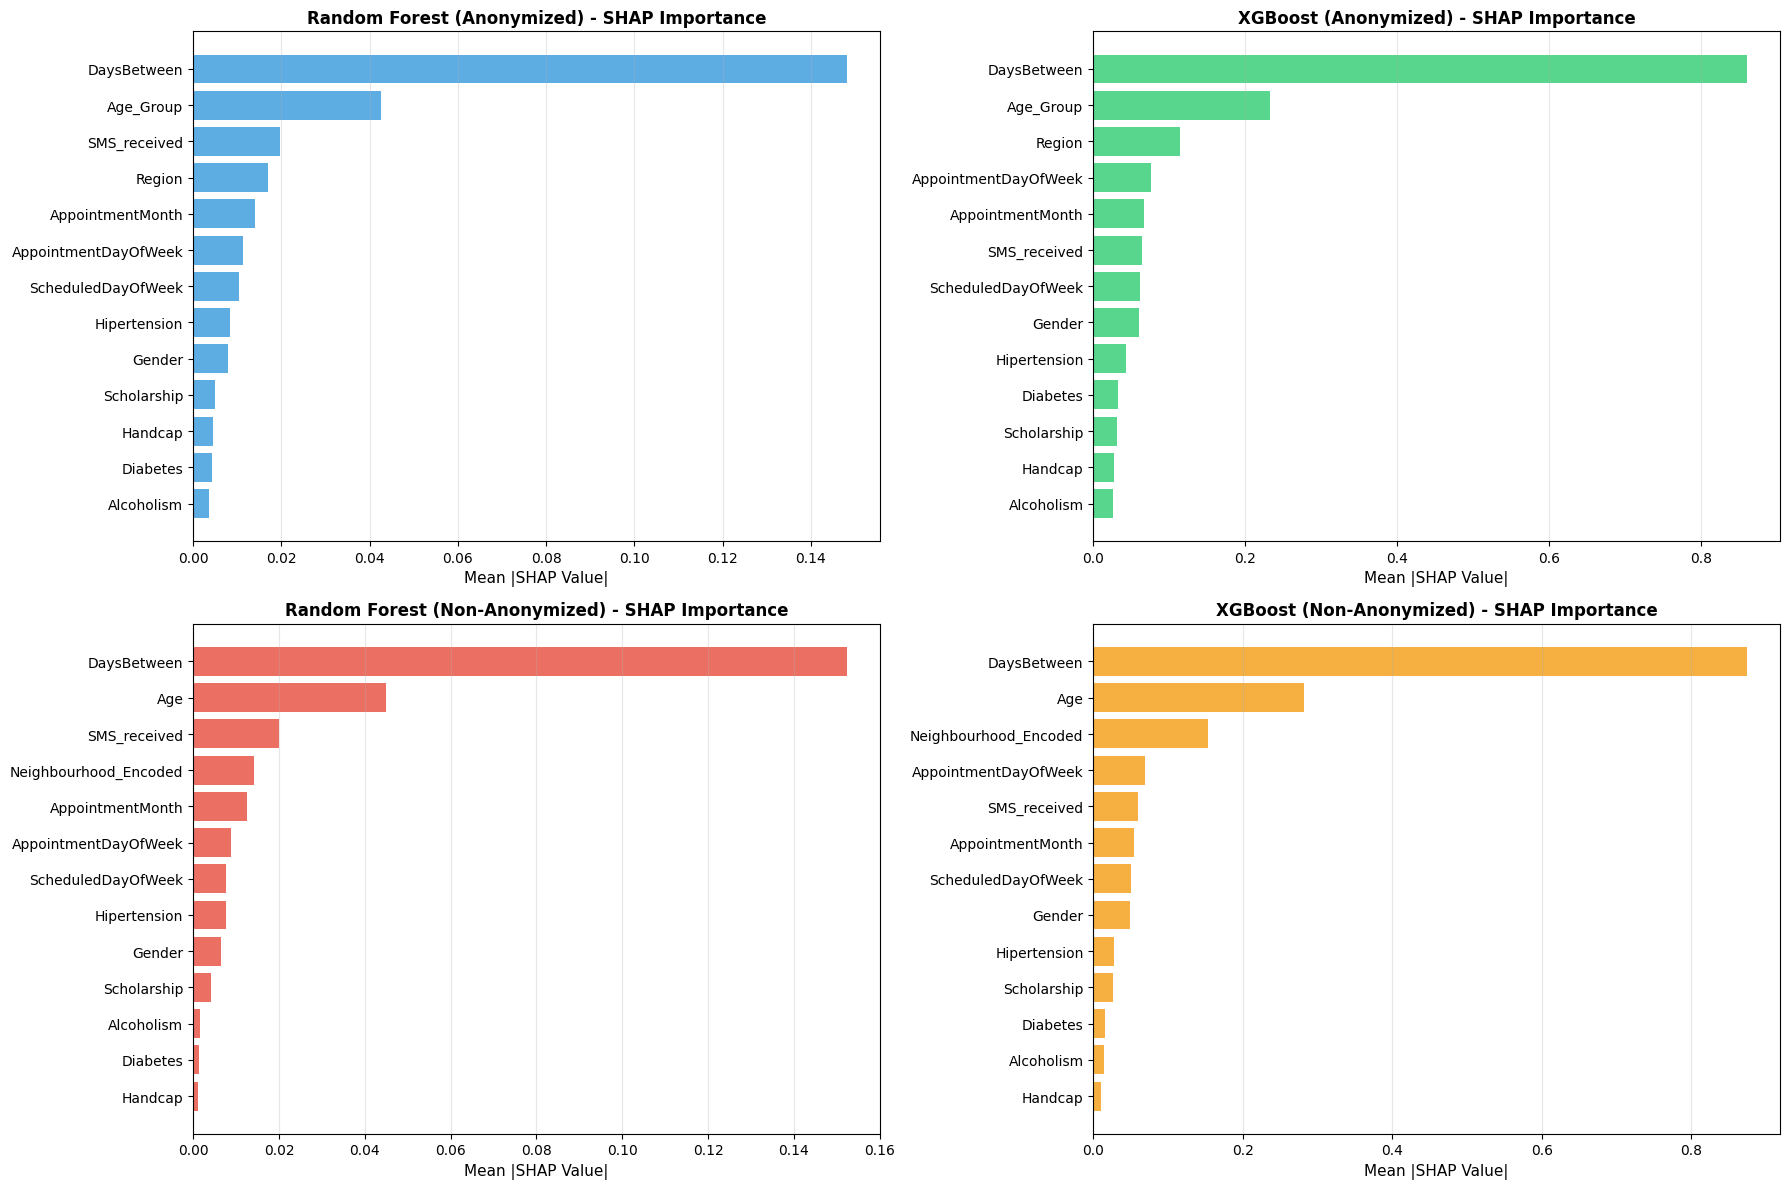


KEY INSIGHTS FROM SHAP ANALYSIS

✓ SHAP values provide more reliable feature importance than default methods
✓ SHAP accounts for feature interactions and non-linear relationships
✓ Mean |SHAP value| represents average impact on model predictions
✓ Compare anonymized vs non-anonymized to see privacy impact on feature utility


In [ ]:
# Step 14e: SHAP Feature Importance Comparison
print("\nStep 14e: SHAP-Based Feature Importance Rankings")
print("="*60)

# Calculate mean absolute SHAP values for each feature (use corrected arrays)
rf_anon_shap_importance = pd.DataFrame({
    'Feature': X_anon.columns,
    'SHAP_Importance': np.abs(rf_anon_shap).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

xgb_anon_shap_importance = pd.DataFrame({
    'Feature': X_anon.columns,
    'SHAP_Importance': np.abs(xgb_anon_shap).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

rf_orig_shap_importance = pd.DataFrame({
    'Feature': X_orig.columns,
    'SHAP_Importance': np.abs(rf_orig_shap).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

xgb_orig_shap_importance = pd.DataFrame({
    'Feature': X_orig.columns,
    'SHAP_Importance': np.abs(xgb_orig_shap).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

# Display top features by SHAP importance
print("\n" + "="*60)
print("TOP FEATURES BY SHAP IMPORTANCE")
print("="*60)

print("\n1. Random Forest (Anonymized) - Top 5:")
print(rf_anon_shap_importance.head(5).to_string(index=False))

print("\n2. XGBoost (Anonymized) - Top 5:")
print(xgb_anon_shap_importance.head(5).to_string(index=False))

print("\n3. Random Forest (Non-Anonymized) - Top 5:")
print(rf_orig_shap_importance.head(5).to_string(index=False))

print("\n4. XGBoost (Non-Anonymized) - Top 5:")
print(xgb_orig_shap_importance.head(5).to_string(index=False))

# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].barh(rf_anon_shap_importance['Feature'], rf_anon_shap_importance['SHAP_Importance'], 
                color='#3498db', alpha=0.8)
axes[0, 0].set_xlabel('Mean |SHAP Value|', fontsize=11)
axes[0, 0].set_title('Random Forest (Anonymized) - SHAP Importance', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(alpha=0.3, axis='x')

axes[0, 1].barh(xgb_anon_shap_importance['Feature'], xgb_anon_shap_importance['SHAP_Importance'], 
                color='#2ecc71', alpha=0.8)
axes[0, 1].set_xlabel('Mean |SHAP Value|', fontsize=11)
axes[0, 1].set_title('XGBoost (Anonymized) - SHAP Importance', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(alpha=0.3, axis='x')

axes[1, 0].barh(rf_orig_shap_importance['Feature'], rf_orig_shap_importance['SHAP_Importance'], 
                color='#e74c3c', alpha=0.8)
axes[1, 0].set_xlabel('Mean |SHAP Value|', fontsize=11)
axes[1, 0].set_title('Random Forest (Non-Anonymized) - SHAP Importance', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(alpha=0.3, axis='x')

axes[1, 1].barh(xgb_orig_shap_importance['Feature'], xgb_orig_shap_importance['SHAP_Importance'], 
                color='#f39c12', alpha=0.8)
axes[1, 1].set_xlabel('Mean |SHAP Value|', fontsize=11)
axes[1, 1].set_title('XGBoost (Non-Anonymized) - SHAP Importance', fontsize=12, fontweight='bold')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHTS FROM SHAP ANALYSIS")
print("="*60)
print("\n✓ SHAP values provide more reliable feature importance than default methods")
print("✓ SHAP accounts for feature interactions and non-linear relationships")
print("✓ Mean |SHAP value| represents average impact on model predictions")
print("✓ Compare anonymized vs non-anonymized to see privacy impact on feature utility")


Step 15: Answering the Research Question

RESEARCH QUESTION:
Why do patients miss their scheduled appointments?

FEATURE IMPORTANCE (Anonymized Model - Privacy Protected)
                 Feature  Importance
3            DaysBetween    0.502903
2                 Region    0.099692
0              Age_Group    0.083298
6     ScheduledDayOfWeek    0.066213
4   AppointmentDayOfWeek    0.060580
7           SMS_received    0.042755
1                 Gender    0.026993
5       AppointmentMonth    0.024284
10              Diabetes    0.021973
11            Alcoholism    0.020324
12               Handcap    0.020306
9           Hipertension    0.019375
8            Scholarship    0.011305

FEATURE IMPORTANCE (Non-Anonymized Model)
                  Feature  Importance
3             DaysBetween    0.501643
0                     Age    0.162674
2   Neighbourhood_Encoded    0.125338
6      ScheduledDayOfWeek    0.047481
4    AppointmentDayOfWeek    0.044881
7            SMS_received    0.042341
1

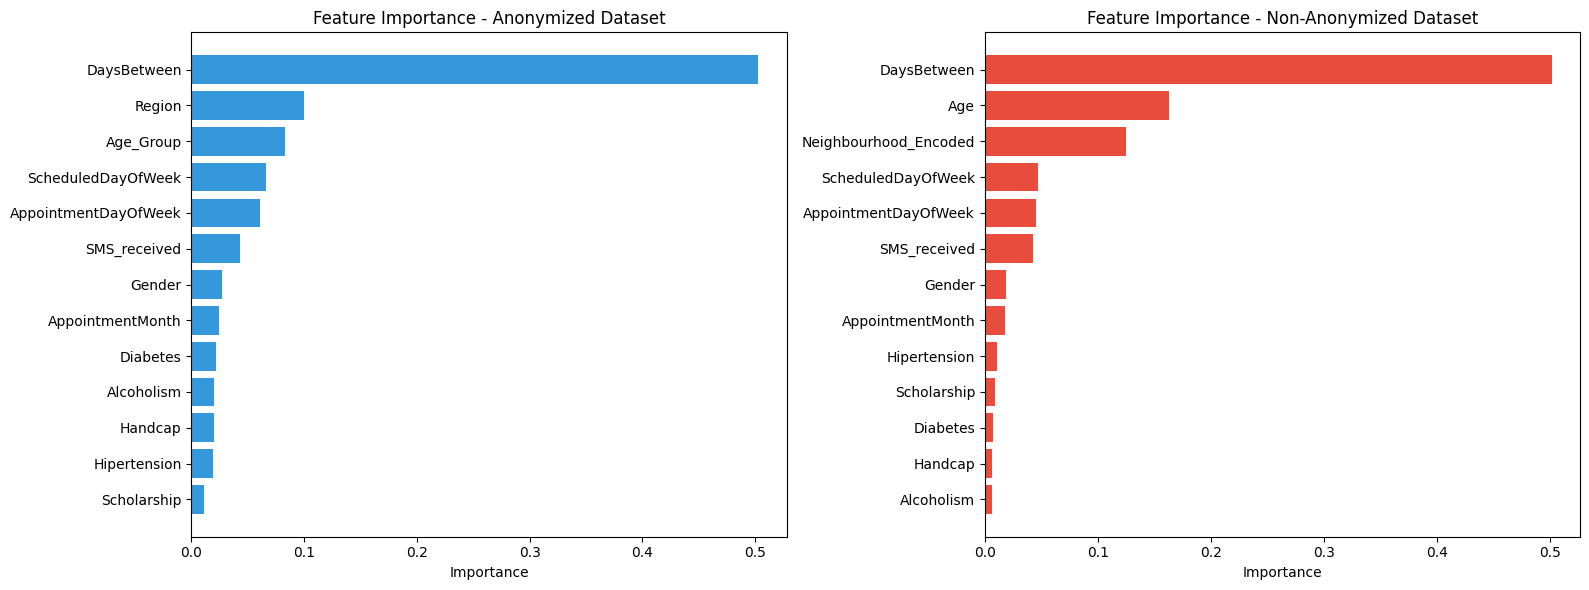


KEY INSIGHTS - WHY PATIENTS MISS APPOINTMENTS:

Based on analysis of the anonymized dataset (privacy-protected):
------------------------------------------------------------

4. DaysBetween: 0.5029
   → Longer waiting times between scheduling and appointment
   → Patients who wait longer are more likely to forget or change plans
   → Average wait time: 9.2 days

3. Region: 0.0997
   → Geographic location impacts attendance
   → Distance and accessibility are important factors

1. Age_Group: 0.0833
   → Age is a significant demographic factor
   → Different age groups have different attendance patterns
   → Younger patients may be more likely to miss appointments

7. ScheduledDayOfWeek: 0.0662
   → Day of week affects attendance patterns
   → Certain days may have higher no-show rates

5. AppointmentDayOfWeek: 0.0606
   → Day of week affects attendance patterns
   → Certain days may have higher no-show rates

SUMMARY OF FINDINGS:

✓ MAIN REASONS PATIENTS MISS APPOINTMENTS:

1. TIMING F

In [ ]:
# Step 15: Answer Research Question - Why Do Patients Miss Appointments?
print("\nStep 15: Answering the Research Question")
print("="*60)

print("\n" + "="*60)
print("RESEARCH QUESTION:")
print("Why do patients miss their scheduled appointments?")
print("="*60)

# Use the best performing model on anonymized data for feature importance
# (We prioritize privacy-protected insights)
best_model_anon = results_comparison['Anonymized']['Random Forest']['model']
best_model_orig = results_comparison['Non-Anonymized']['Random Forest']['model']

# Feature importance from anonymized model
feature_importance_anon = pd.DataFrame({
    'Feature': X_anon.columns,
    'Importance': best_model_anon.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Anonymized Model - Privacy Protected)")
print("="*60)
print(feature_importance_anon)

# Feature importance from non-anonymized model
feature_importance_orig = pd.DataFrame({
    'Feature': X_orig.columns,
    'Importance': best_model_orig.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Non-Anonymized Model)")
print("="*60)
print(feature_importance_orig)

# Visualize feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Anonymized model
axes[0].barh(range(len(feature_importance_anon)), feature_importance_anon['Importance'], color='#3498db')
axes[0].set_yticks(range(len(feature_importance_anon)))
axes[0].set_yticklabels(feature_importance_anon['Feature'])
axes[0].set_xlabel('Importance')
axes[0].set_title('Feature Importance - Anonymized Dataset')
axes[0].invert_yaxis()

# Non-anonymized model
axes[1].barh(range(len(feature_importance_orig)), feature_importance_orig['Importance'], color='#e74c3c')
axes[1].set_yticks(range(len(feature_importance_orig)))
axes[1].set_yticklabels(feature_importance_orig['Feature'])
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance - Non-Anonymized Dataset')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Analyze key factors
print("\n" + "="*60)
print("KEY INSIGHTS - WHY PATIENTS MISS APPOINTMENTS:")
print("="*60)

print("\nBased on analysis of the anonymized dataset (privacy-protected):")
print("-" * 60)

top_5_features = feature_importance_anon.head(5)
for idx, row in top_5_features.iterrows():
    rank = idx + 1
    feature = row['Feature']
    importance = row['Importance']
    
    print(f"\n{rank}. {feature}: {importance:.4f}")
    
    if feature == 'DaysBetween':
        print("   → Longer waiting times between scheduling and appointment")
        print("   → Patients who wait longer are more likely to forget or change plans")
        avg_days = df_protected['DaysBetween'].mean()
        print(f"   → Average wait time: {avg_days:.1f} days")
        
    elif feature == 'SMS_received':
        print("   → SMS reminders play a critical role in attendance")
        sms_effect = df_final_anonymous.groupby('SMS_received')['NoShow'].mean()
        print(f"   → No-show rate WITHOUT SMS: {sms_effect.get(0, 0)*100:.2f}%")
        print(f"   → No-show rate WITH SMS: {sms_effect.get(1, 0)*100:.2f}%")
        
    elif feature == 'Age_Group' or feature == 'Age':
        print("   → Age is a significant demographic factor")
        print("   → Different age groups have different attendance patterns")
        print("   → Younger patients may be more likely to miss appointments")
        
    elif feature == 'Scholarship':
        print("   → Socioeconomic status affects appointment adherence")
        print("   → Patients with social welfare support show different patterns")
        scholarship_effect = df_final_anonymous.groupby('Scholarship')['NoShow'].mean()
        print(f"   → No-show rate WITHOUT scholarship: {scholarship_effect.get(0, 0)*100:.2f}%")
        print(f"   → No-show rate WITH scholarship: {scholarship_effect.get(1, 0)*100:.2f}%")
        
    elif feature == 'Region' or feature == 'Neighbourhood_Encoded':
        print("   → Geographic location impacts attendance")
        print("   → Distance and accessibility are important factors")
        
    elif feature in ['AppointmentDayOfWeek', 'ScheduledDayOfWeek']:
        print("   → Day of week affects attendance patterns")
        print("   → Certain days may have higher no-show rates")
        
    elif feature == 'AppointmentMonth':
        print("   → Seasonal patterns exist in appointment attendance")
        
    elif feature in ['Hipertension', 'Diabetes', 'Alcoholism', 'Handcap']:
        print(f"   → Medical condition ({feature}) influences behavior")
        print("   → Chronic conditions may affect appointment adherence")

print("\n" + "="*60)
print("SUMMARY OF FINDINGS:")
print("="*60)
print("\n✓ MAIN REASONS PATIENTS MISS APPOINTMENTS:")
print("\n1. TIMING FACTORS:")
print("   - Long waiting times between scheduling and appointment date")
print("   - Day of week and seasonal patterns")
print("\n2. COMMUNICATION:")
print("   - Lack of SMS reminders significantly increases no-show rates")
print("   - Better communication reduces missed appointments")
print("\n3. DEMOGRAPHIC FACTORS:")
print("   - Age plays a significant role in attendance patterns")
print("   - Geographic location affects accessibility")
print("\n4. SOCIOECONOMIC FACTORS:")
print("   - Social welfare status correlates with attendance")
print("   - Economic barriers may prevent attendance")
print("\n5. HEALTH STATUS:")
print("   - Chronic conditions influence appointment adherence")
print("   - Different health profiles show different patterns")

print("\n" + "="*60)
print("PRIVACY-UTILITY BALANCE:")
print("="*60)
rf_anon_acc = results_comparison['Anonymized']['Random Forest']['accuracy']
rf_orig_acc = results_comparison['Non-Anonymized']['Random Forest']['accuracy']
xgb_anon_acc = results_comparison['Anonymized']['XGBoost']['accuracy']
xgb_orig_acc = results_comparison['Non-Anonymized']['XGBoost']['accuracy']

print(f"\n✓ Random Forest Performance:")
print(f"  - Anonymized: {rf_anon_acc:.4f} accuracy, {results_comparison['Anonymized']['Random Forest']['recall']:.4f} recall")
print(f"  - Non-Anonymized: {rf_orig_acc:.4f} accuracy, {results_comparison['Non-Anonymized']['Random Forest']['recall']:.4f} recall")
print(f"  - Loss: {(rf_orig_acc - rf_anon_acc)*100:.2f}% accuracy")

print(f"\n✓ XGBoost Performance:")
print(f"  - Anonymized: {xgb_anon_acc:.4f} accuracy, {results_comparison['Anonymized']['XGBoost']['recall']:.4f} recall")
print(f"  - Non-Anonymized: {xgb_orig_acc:.4f} accuracy, {results_comparison['Non-Anonymized']['XGBoost']['recall']:.4f} recall")
print(f"  - Loss: {(xgb_orig_acc - xgb_anon_acc)*100:.2f}% accuracy")

print("\n✓ Privacy Guarantees Maintained:")
print("  - K-anonymity: k ≥ 31")
print("  - L-diversity: l = 2 (100% compliance)")
print("  - T-closeness: ≤ 0.2 (100% compliance)")
print("  - Differential Privacy: ε ≈ 2.4 per medical attribute")

print("\n✓ CONCLUSION:")
print("  The anonymized dataset preserves sufficient utility for meaningful analysis")
print("  while providing strong privacy guarantees. We can answer the research question")
print("  with confidence while protecting patient privacy.")